# **<font face='Arial Black' color='#FF6F59'> Finals ALA: Analytics Techniques and Tools </font>**

## **<font face='Monaco' color='#E0E0E0'> West Visayas State University </font>**
#### **<font face='Lucida Handwriting' color='#8FBC8F'> Submitted to: Prof. Paolo Hilado MSc. (Data Science) </font>**

***

### **<font face='Courier New' color='#48D1CC'> Student: </font>**
* **Submitted by:** Florence Elaine G. Soleño  
* **Section:** BSIS 3-B  
* **Date:** May 26, 2026  

***

# **<font face='Arial Black' color='#FF6F59'>Project Introduction </font>**

For this finals project, I wanted to look into how the environments we build affect public health and early development, focusing closely on **SDG 3 (Good Health and Well-being)** and **SDG 11 (Sustainable Cities and Communities)**. I am using a real-world dataset containing records from 543 public elementary school districts across California. This data tracks childhood autism counts and rates alongside specific environmental indicators—like average tree canopy cover (`Avecanopy`), near-road vegetation, and traffic road density (`Roadensity`). The core question driving this entire study is:

#### <font face='Lucida Handwriting' color='#48D1CC'>
What environmental factors influence childhood autism rates across these districts, and can green spaces act as a protective buffer against urban traffic strains?</font>



Instead of just creating static visualizations, I am building an objective, end-to-end regression analysis directly in this notebook. I will start by loading the dataset and cleaning it up—especially handling the missing values found in the road canopy columns (`Prdcan100` and `Prdcan50`). Next, I'll perform an exploratory data analysis to test if the data meets standard ordinary least squares assumptions or if we need to switch to robust regression models to better handle any outliers. By running these multiple regression models and grounding my choice of variables in existing environmental health literature, I want to isolate exactly which variables play a statistically significant role. Finally, I will turn these statistical insights into an interactive Python dashboard, complete with a time-based slider and dynamic trend lines, so that users can filter through the data and see how these relationships look across different districts.


# **<font face='Arial Black' color='#FF6F59'> Sustainable Development Goals Framing </font>**

### **<font face='Arial' color='#48D1CC'> SDG 3: Good Health and Well-Being </font>**

SDG 3 aims to promote healthy lives and improve well-being across all age groups. Childhood autism prevalence is an important public health indicator because understanding environmental and community conditions associated with developmental outcomes can help support healthier living environments. Research by Wu and Jackson (2017) highlights the importance of examining environmental exposures such as green space and traffic-related conditions when exploring patterns in childhood autism prevalence.

### **<font face='Arial' color='#48D1CC'> SDG 11: Sustainable Cities and Communities </font>**

SDG 11 focuses on creating inclusive, safe, resilient, and sustainable communities through improved urban planning and environmental quality. Variables within this study, including tree canopy coverage, green space exposure, road density, and population density, directly reflect characteristics of urban environments that influence community livability. According to Wu and Jackson (2017), districts with greater access to urban green space exhibited different autism prevalence patterns, emphasizing the potential role of sustainable environmental design in shaping healthier communities.


References:


Wu, J., & Jackson, L. (2017). Inverse relationship between urban green space and childhood autism in California elementary school districts. Environment International, 107, 140–146.https://pubmed.ncbi.nlm.nih.gov/28735150/

United Nations. (2015). Transforming our world: The 2030 Agenda for Sustainable Development. https://sdgs.un.org/2030agenda

# **<font face='Arial Black' color='#FF6F59'>Environmental Vulnerability & Autism Pattern Dashboard</font>**

This project explores environmental vulnerability patterns and childhood autism prevalence across California elementary school districts. The analysis focuses on how environmental conditions such as urban green space, road density, population density, and socioeconomic characteristics vary across communities and how these patterns may relate to differences in autism prevalence.

The dataset was obtained from AmeriGEOSS / Data.gov and is based on the study <font face='Arial' color='#48D1CC'> Inverse Relationship Between Urban Green Space and Childhood Autism in California Elementary School Districts</font >by Wu and Jackson (2017).

The dashboard is designed to support  <font face='Arial' color='#48D1CC'> SDG 3 (Good Health and Well-Being)</font> and  <font face='Arial' color='#48D1CC'> SDG 11 (Sustainable Cities and Communities) </font> by examining environmental conditions that may contribute to healthier and more sustainable urban environments.

In [57]:
# Install necessary libraries


!pip install pandas numpy matplotlib seaborn plotly scipy qdesc statsmodels scikit-learn openpyxl --quiet

In [58]:
# Import necessary libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import qdesc as qd

from scipy import stats
from scipy.stats import shapiro, spearmanr, kendalltau, pearsonr

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.robust.norms import HuberT, TukeyBiweight, Hampel

from sklearn.preprocessing import StandardScaler


from google.colab import files

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

In [10]:
# Load dataset

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df_raw = pd.read_csv(file_name)

print("Dataset successfully loaded.")
display(df_raw.head())
display(df_raw.tail())

print("Shape:", df_raw.shape)
print("\nColumn Names:")
print(df_raw.columns.tolist())

Saving autism and green space_clean.csv to autism and green space_clean.csv
Dataset successfully loaded.


,DistrictID,Autism,Kstudent,Rate,Area_km,LC11,LC21,LC2B,LC31,LC4,LC52,LC71,LC8,LC9,Avecanopy,Prdcan100,Prdcan50,Roadensity,Rd4,Pop,Popm,Popf,Malep,Femalep,Popden,Age19l,Age65m,Whitep,Blackp,Asisanp,Vehicle0,Unemploy,Income_median,Income_sd_median,RLC2b,RLC4,RLC71,Rcanopy,Rroadcan100,Rroadcan50,LC1106,LC2106,LC2B06,LC3106,LC406,LC5206,LC7106,LC806,LC906,RLC2B06,RLC406,RLC7106
0,1,1,338,2.96,11.3,0.04,8.81,17.41,0.00,60.02,2.78,10.95,0.00,0.00,46.74,26.52,19.28,1.449,4,2852,1452,1400,50.91,49.09,252.39,25.32,12.66,95.72,0.67,2.77,2.46,3.58,65139,6.5139,1.741,6.002,1.095,4.674,2.652,1.928,0.04,8.81,17.29,0.00,60.57,2.59,10.70,0.00,0.00,1.729,6.057,1.070
1,2,54,5516,9.79,868.6,0.01,3.31,3.57,6.03,0.01,86.55,0.23,0.21,0.07,0.02,0.00,0.00,0.176,2,47571,26705,20866,56.14,43.86,54.77,38.56,4.67,62.33,17.81,4.68,5.76,16.71,50395,5.0395,0.357,0.001,0.023,0.002,0.000,0.000,0.01,3.14,2.96,6.03,0.02,87.33,0.23,0.21,0.07,0.296,0.002,0.023
2,3,0,111,0.00,171.6,0.19,3.05,1.21,0.15,37.29,26.32,21.42,10.03,0.33,32.25,10.14,10.39,0.090,1,1260,786,474,62.38,37.62,7.34,17.62,15.79,73.65,1.83,0.40,2.59,6.30,75903,7.5903,0.121,3.729,2.142,3.225,1.014,1.039,0.19,3.05,1.21,0.16,37.30,26.27,21.46,10.02,0.33,0.121,3.730,2.146
3,4,16,6837,2.34,169.0,0.17,5.07,9.46,0.04,19.55,21.22,21.27,22.76,0.46,13.93,0.06,0.05,0.298,3,54943,28244,26699,51.41,48.59,325.11,39.59,4.38,68.23,1.37,6.24,7.68,13.83,48597,4.8597,0.946,1.955,2.127,1.393,0.006,0.005,0.17,5.15,9.18,0.04,19.56,21.23,21.28,22.92,0.47,0.918,1.956,2.128
4,5,0,53,0.00,52.4,0.00,3.01,1.67,0.89,0.00,0.00,30.53,63.70,0.20,0.00,0.00,0.00,0.174,2,210,104,106,49.52,50.48,4.01,38.10,5.24,63.33,21.43,0.00,16.67,47.56,19375,1.9375,0.167,0.000,3.053,0.000,0.000,0.000,0.00,3.00,1.67,0.89,0.00,0.00,31.53,62.71,0.20,0.167,0.000,3.153


,DistrictID,Autism,Kstudent,Rate,Area_km,LC11,LC21,LC2B,LC31,LC4,LC52,LC71,LC8,LC9,Avecanopy,Prdcan100,Prdcan50,Roadensity,Rd4,Pop,Popm,Popf,Malep,Femalep,Popden,Age19l,Age65m,Whitep,Blackp,Asisanp,Vehicle0,Unemploy,Income_median,Income_sd_median,RLC2b,RLC4,RLC71,Rcanopy,Rroadcan100,Rroadcan50,LC1106,LC2106,LC2B06,LC3106,LC406,LC5206,LC7106,LC806,LC906,RLC2B06,RLC406,RLC7106
538,545,2,1030,1.94,396.4,1.33,2.71,1.22,0.30,11.13,13.11,53.55,16.43,0.21,10.09,1.23,1.23,0.108,1,9564,4938,4626,51.63,48.37,24.13,37.59,7.96,75.17,0.78,0.39,8.68,16.14,34115,3.4115,0.122,1.113,5.355,1.009,0.123,0.123,1.30,2.72,1.20,0.29,11.14,13.13,53.51,16.50,0.21,0.120,1.114,5.351
539,546,0,312,0.00,30.4,0.00,30.05,5.13,0.00,61.26,0.40,2.90,0.24,0.02,67.24,53.66,51.66,1.043,4,3433,1730,1703,50.39,49.61,112.93,32.48,13.66,95.51,0.00,7.49,0.00,4.30,197250,19.7250,0.513,6.126,0.290,6.724,5.366,5.166,0.00,30.08,5.11,0.00,61.26,0.40,2.88,0.24,0.02,0.511,6.126,0.288
540,547,1,379,2.64,49.4,0.00,3.16,1.60,0.26,0.00,0.00,2.10,92.88,0.00,0.16,0.01,0.05,0.162,2,2799,1459,1340,52.13,47.87,56.66,45.77,4.18,72.53,0.00,0.14,11.05,13.40,26469,2.6469,0.160,0.000,0.210,0.016,0.001,0.005,0.00,3.16,1.59,0.26,0.00,0.00,2.10,92.88,0.00,0.159,0.000,0.210
541,548,14,1289,10.86,13.8,0.41,19.95,51.19,0.00,0.00,0.04,14.73,13.67,0.00,0.28,0.41,0.33,1.860,4,15764,8264,7500,52.42,47.58,1142.32,27.39,8.54,71.03,3.46,9.94,3.11,9.39,66894,6.6894,5.119,0.000,1.473,0.028,0.041,0.033,0.18,20.14,50.90,0.00,0.00,0.04,15.10,13.64,0.00,5.090,0.000,1.510
542,549,5,667,7.50,420.2,0.12,3.75,2.25,0.36,33.20,43.81,11.89,4.51,0.09,38.87,8.27,6.34,0.226,2,9380,4652,4728,49.59,50.41,22.32,23.61,22.04,93.91,0.67,0.53,10.47,9.64,35133,3.5133,0.225,3.320,1.189,3.887,0.827,0.634,0.11,3.75,2.21,0.42,33.32,43.59,11.99,4.51,0.10,0.221,3.332,1.199


Shape: (543, 52)

Column Names:
['DistrictID', 'Autism', 'Kstudent', 'Rate', 'Area_km', 'LC11', 'LC21', 'LC2B', 'LC31', 'LC4', 'LC52', 'LC71', 'LC8', 'LC9', 'Avecanopy', 'Prdcan100', 'Prdcan50', 'Roadensity', 'Rd4', 'Pop', 'Popm', 'Popf', 'Malep', 'Femalep', 'Popden', 'Age19l', 'Age65m', 'Whitep', 'Blackp', 'Asisanp', 'Vehicle0', 'Unemploy', 'Income_median', 'Income_sd_median', 'RLC2b', 'RLC4', 'RLC71', 'Rcanopy', 'Rroadcan100', 'Rroadcan50', 'LC1106', 'LC2106', 'LC2B06', 'LC3106', 'LC406', 'LC5206', 'LC7106', 'LC806', 'LC906', 'RLC2B06', 'RLC406', 'RLC7106']


## **INITIAL DATASET INSPECTION**

In [19]:
# Show first 5 rows

print("First 5 rows:")
display(df_raw.head())

First 5 rows:


,DistrictID,Autism,Kstudent,Rate,Area_km,LC11,LC21,LC2B,LC31,LC4,LC52,LC71,LC8,LC9,Avecanopy,Prdcan100,Prdcan50,Roadensity,Rd4,Pop,Popm,Popf,Malep,Femalep,Popden,Age19l,Age65m,Whitep,Blackp,Asisanp,Vehicle0,Unemploy,Income_median,Income_sd_median,RLC2b,RLC4,RLC71,Rcanopy,Rroadcan100,Rroadcan50,LC1106,LC2106,LC2B06,LC3106,LC406,LC5206,LC7106,LC806,LC906,RLC2B06,RLC406,RLC7106
0,1,1,338,2.96,11.3,0.04,8.81,17.41,0.00,60.02,2.78,10.95,0.00,0.00,46.74,26.52,19.28,1.449,4,2852,1452,1400,50.91,49.09,252.39,25.32,12.66,95.72,0.67,2.77,2.46,3.58,65139,6.5139,1.741,6.002,1.095,4.674,2.652,1.928,0.04,8.81,17.29,0.00,60.57,2.59,10.70,0.00,0.00,1.729,6.057,1.070
1,2,54,5516,9.79,868.6,0.01,3.31,3.57,6.03,0.01,86.55,0.23,0.21,0.07,0.02,0.00,0.00,0.176,2,47571,26705,20866,56.14,43.86,54.77,38.56,4.67,62.33,17.81,4.68,5.76,16.71,50395,5.0395,0.357,0.001,0.023,0.002,0.000,0.000,0.01,3.14,2.96,6.03,0.02,87.33,0.23,0.21,0.07,0.296,0.002,0.023
2,3,0,111,0.00,171.6,0.19,3.05,1.21,0.15,37.29,26.32,21.42,10.03,0.33,32.25,10.14,10.39,0.090,1,1260,786,474,62.38,37.62,7.34,17.62,15.79,73.65,1.83,0.40,2.59,6.30,75903,7.5903,0.121,3.729,2.142,3.225,1.014,1.039,0.19,3.05,1.21,0.16,37.30,26.27,21.46,10.02,0.33,0.121,3.730,2.146
3,4,16,6837,2.34,169.0,0.17,5.07,9.46,0.04,19.55,21.22,21.27,22.76,0.46,13.93,0.06,0.05,0.298,3,54943,28244,26699,51.41,48.59,325.11,39.59,4.38,68.23,1.37,6.24,7.68,13.83,48597,4.8597,0.946,1.955,2.127,1.393,0.006,0.005,0.17,5.15,9.18,0.04,19.56,21.23,21.28,22.92,0.47,0.918,1.956,2.128
4,5,0,53,0.00,52.4,0.00,3.01,1.67,0.89,0.00,0.00,30.53,63.70,0.20,0.00,0.00,0.00,0.174,2,210,104,106,49.52,50.48,4.01,38.10,5.24,63.33,21.43,0.00,16.67,47.56,19375,1.9375,0.167,0.000,3.053,0.000,0.000,0.000,0.00,3.00,1.67,0.89,0.00,0.00,31.53,62.71,0.20,0.167,0.000,3.153


In [20]:
# Show last 5 rows

print("Last 5 rows:")
display(df_raw.tail())

Last 5 rows:


,DistrictID,Autism,Kstudent,Rate,Area_km,LC11,LC21,LC2B,LC31,LC4,LC52,LC71,LC8,LC9,Avecanopy,Prdcan100,Prdcan50,Roadensity,Rd4,Pop,Popm,Popf,Malep,Femalep,Popden,Age19l,Age65m,Whitep,Blackp,Asisanp,Vehicle0,Unemploy,Income_median,Income_sd_median,RLC2b,RLC4,RLC71,Rcanopy,Rroadcan100,Rroadcan50,LC1106,LC2106,LC2B06,LC3106,LC406,LC5206,LC7106,LC806,LC906,RLC2B06,RLC406,RLC7106
538,545,2,1030,1.94,396.4,1.33,2.71,1.22,0.30,11.13,13.11,53.55,16.43,0.21,10.09,1.23,1.23,0.108,1,9564,4938,4626,51.63,48.37,24.13,37.59,7.96,75.17,0.78,0.39,8.68,16.14,34115,3.4115,0.122,1.113,5.355,1.009,0.123,0.123,1.30,2.72,1.20,0.29,11.14,13.13,53.51,16.50,0.21,0.120,1.114,5.351
539,546,0,312,0.00,30.4,0.00,30.05,5.13,0.00,61.26,0.40,2.90,0.24,0.02,67.24,53.66,51.66,1.043,4,3433,1730,1703,50.39,49.61,112.93,32.48,13.66,95.51,0.00,7.49,0.00,4.30,197250,19.7250,0.513,6.126,0.290,6.724,5.366,5.166,0.00,30.08,5.11,0.00,61.26,0.40,2.88,0.24,0.02,0.511,6.126,0.288
540,547,1,379,2.64,49.4,0.00,3.16,1.60,0.26,0.00,0.00,2.10,92.88,0.00,0.16,0.01,0.05,0.162,2,2799,1459,1340,52.13,47.87,56.66,45.77,4.18,72.53,0.00,0.14,11.05,13.40,26469,2.6469,0.160,0.000,0.210,0.016,0.001,0.005,0.00,3.16,1.59,0.26,0.00,0.00,2.10,92.88,0.00,0.159,0.000,0.210
541,548,14,1289,10.86,13.8,0.41,19.95,51.19,0.00,0.00,0.04,14.73,13.67,0.00,0.28,0.41,0.33,1.860,4,15764,8264,7500,52.42,47.58,1142.32,27.39,8.54,71.03,3.46,9.94,3.11,9.39,66894,6.6894,5.119,0.000,1.473,0.028,0.041,0.033,0.18,20.14,50.90,0.00,0.00,0.04,15.10,13.64,0.00,5.090,0.000,1.510
542,549,5,667,7.50,420.2,0.12,3.75,2.25,0.36,33.20,43.81,11.89,4.51,0.09,38.87,8.27,6.34,0.226,2,9380,4652,4728,49.59,50.41,22.32,23.61,22.04,93.91,0.67,0.53,10.47,9.64,35133,3.5133,0.225,3.320,1.189,3.887,0.827,0.634,0.11,3.75,2.21,0.42,33.32,43.59,11.99,4.51,0.10,0.221,3.332,1.199


In [21]:
# Show shape of the dataset

print("Shape:")
print(df_raw.shape)

Shape:
(543, 52)


In [22]:
# Show information about the dataset and its features

print("Info:")
df_raw.info()

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543 entries, 0 to 542
Data columns (total 52 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   DistrictID        543 non-null    int64  
 1   Autism            543 non-null    int64  
 2   Kstudent          543 non-null    int64  
 3   Rate              543 non-null    float64
 4   Area_km           543 non-null    float64
 5   LC11              543 non-null    float64
 6   LC21              543 non-null    float64
 7   LC2B              543 non-null    float64
 8   LC31              543 non-null    float64
 9   LC4               543 non-null    float64
 10  LC52              543 non-null    float64
 11  LC71              543 non-null    float64
 12  LC8               543 non-null    float64
 13  LC9               543 non-null    float64
 14  Avecanopy         543 non-null    float64
 15  Prdcan100         535 non-null    float64
 16  Prdcan50          535 non-null    floa

In [23]:
# Show initial descriptive statistics

print("Descriptive Statistics:")
display(df_raw.describe())

Descriptive Statistics:


,DistrictID,Autism,Kstudent,Rate,Area_km,LC11,LC21,LC2B,LC31,LC4,LC52,LC71,LC8,LC9,Avecanopy,Prdcan100,Prdcan50,Roadensity,Rd4,Pop,Popm,Popf,Malep,Femalep,Popden,Age19l,Age65m,Whitep,Blackp,Asisanp,Vehicle0,Unemploy,Income_median,Income_sd_median,RLC2b,RLC4,RLC71,Rcanopy,Rroadcan100,Rroadcan50,LC1106,LC2106,LC2B06,LC3106,LC406,LC5206,LC7106,LC806,LC906,RLC2B06,RLC406,RLC7106
count,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,535.000000,535.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,542.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,535.000000,535.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000,543.000000
mean,274.847145,15.117864,1532.642726,6.844273,238.110866,1.347974,7.377661,16.164936,1.459153,20.859632,13.481492,16.445157,21.885875,0.971289,18.377366,12.633047,11.585308,0.686602,2.499079,18626.843462,9351.318600,9275.524862,50.903076,49.096943,444.508932,27.917808,13.121639,79.422762,2.729834,6.406464,3.885277,8.410221,60859.292818,6.085929,1.616494,2.085963,1.644516,1.837737,1.263305,1.158531,1.374770,7.382670,15.852855,1.451308,21.066796,13.444475,16.437956,22.019724,0.963223,1.585285,2.106680,1.643796
std,159.316797,30.789922,2670.314715,7.772298,371.207549,3.734456,7.500128,26.761498,5.085079,27.926774,17.797063,20.476282,31.692262,1.933063,23.275496,18.762086,17.805262,0.967787,1.119889,31141.755135,15539.300328,15634.558098,4.830776,4.830782,954.810651,7.647184,6.760139,16.424364,4.254442,9.559145,3.196479,4.618761,25896.155012,2.589616,2.676150,2.792677,2.047628,2.327550,1.876209,1.780526,3.881784,7.490509,26.507345,5.079023,28.250959,17.971273,20.517439,31.840703,1.931941,2.650735,2.825096,2.051744
min,1.000000,0.000000,2.000000,0.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,44.000000,22.000000,21.000000,27.480000,10.560000,0.040000,4.110000,1.670000,13.860000,0.000000,0.000000,0.000000,0.000000,19375.000000,1.937500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,136.500000,0.000000,115.500000,0.000000,44.150000,0.060000,2.965000,0.695000,0.020000,0.010000,0.085000,1.785000,0.005000,0.020000,0.590000,0.320000,0.195000,0.149500,1.500000,1246.500000,631.000000,618.000000,48.710000,47.540000,7.150000,22.825000,8.600000,71.020000,0.030000,1.070000,1.485000,5.400000,42437.500000,4.243750,0.069500,0.001000,0.178500,0.059000,0.032000,0.019500,0.055000,2.985000,0.685000,0.020000,0.010000,0.055000,1.655000,0.005000,0.020000,0.068500,0.001000,0.165500
50%,276.000000,3.000000,398.000000,5.730000,103.700000,0.240000,5.190000,2.580000,0.210000,4.160000,6.300000,7.070000,2.280000,0.270000,5.240000,1.910000,1.520000,0.284000,2.000000,4645.000000,2379.000000,2303.000000,50.280000,49.720000,43.240000,27.770000,11.760000,84.090000,1.270000,3.170000,3.140000,7.500000,55625.000000,5.562500,0.258000,0.416000,0.707000,0.524000,0.191000,0.152000,0.240000,5.200000,2.550000,0.210000,4.150000,5.970000,7.120000,2.360000,0.270000,0.255000,0.415000,0.712000
75%,413.500000,15.000000,1849.500000,10.665000,254.550000,0.880000,9.015000,17.430000,0.805000,38.060000,20.675000,24.100000,35.410000,1.090000,32.615000,17.900000,15.460000,0.783000,3.500000,21757.500000,10717.000000,10989.500000,52.460000,51.290000,348.795000,33.255000,16.515000,92.190000,3.375000,7.510000,5.562500,10.635000,73303.000000,7.330300,1.743000,3.806000,2.410000,3.261500,1.790000,1.546000,0.875000,8.985000,16.910000,0.815000,38.420000,20.195000,23.920000,35.030000,1.055000,1.691000,3.842000,2.392000
max,549.000000,254.000000,23

In [24]:
# Show any missing values per column


print("Missing Values:")
display(df_raw.isnull().sum().sort_values(ascending=False))

Missing Values:


,0
Prdcan100,8
Prdcan50,8
Rroadcan50,8
Rroadcan100,8
Vehicle0,1
Rate,0
Area_km,0
LC11,0
LC31,0
Kstudent,0


In [25]:
## Shows row that are duplicated

print("Duplicate Rows:")
print(df_raw.duplicated().sum())

Duplicate Rows:
0


In [26]:
# Show frequency distribution of road density categories

print("Unique Rd4 Values:")
display(df_raw["Rd4"].value_counts().sort_index())

Unique Rd4 Values:


,count
Rd4,
1,136
2,136
3,135
4,136


## **SELECT LITERATURE-SUPPORTED VARIABLES ONLY**

In [27]:
# Retain only literature-supported variables for analysis

selected_columns = [
    "DistrictID",
    "Autism",
    "Kstudent",
    "Rate",
    "Prdcan100",
    "Avecanopy",
    "Roadensity",
    "Popden",
    "Income_median",
    "Vehicle0",
    "Unemploy",
    "Rd4"
]

df = df_raw[selected_columns].copy()

print("Selected literature-supported variables only:")
display(df.head())

print("Selected dataset shape:", df.shape)

Selected literature-supported variables only:


,DistrictID,Autism,Kstudent,Rate,Prdcan100,Avecanopy,Roadensity,Popden,Income_median,Vehicle0,Unemploy,Rd4
0,1,1,338,2.96,26.52,46.74,1.449,252.39,65139,2.46,3.58,4
1,2,54,5516,9.79,0.00,0.02,0.176,54.77,50395,5.76,16.71,2
2,3,0,111,0.00,10.14,32.25,0.090,7.34,75903,2.59,6.30,1
3,4,16,6837,2.34,0.06,13.93,0.298,325.11,48597,7.68,13.83,3
4,5,0,53,0.00,0.00,0.00,0.174,4.01,19375,16.67,47.56,2


Selected dataset shape: (543, 12)


In [28]:
# Create a variable basis table

variable_basis = pd.DataFrame({
    "Variable": [
        "Rate", "Prdcan100", "Avecanopy", "Roadensity", "Popden",
        "Income_median", "Vehicle0", "Unemploy", "Rd4",
        "DistrictID", "Autism", "Kstudent"
    ],
    "Role": [
        "Response variable", "Core explanatory variable", "Core explanatory variable",
        "Core explanatory variable", "Control variable", "Socioeconomic control",
        "Socioeconomic control", "Socioeconomic control", "Grouping variable",
        "Identifier", "Supporting count variable", "Supporting denominator variable"
    ],
    "Meaning": [
        "Autism prevalence rate",
        "Near-road tree canopy within 100 meters",
        "Average tree canopy",
        "Road density / urban traffic exposure proxy",
        "Population density",
        "Median income",
        "No vehicle access indicator",
        "Unemployment indicator",
        "Road density group",
        "District identifier",
        "Autism case count",
        "Kindergarten student count"
    ],
    "Reason for Inclusion": [
        "Main health outcome",
        "Directly related to near-road green buffer exposure",
        "Represents general tree canopy exposure",
        "Represents urbanization and traffic exposure",
        "Controls for urban density",
        "Controls socioeconomic variation",
        "Controls mobility and access differences",
        "Controls labor and socioeconomic disadvantage",
        "Used to isolate high-road-density districts",
        "Needed for district-level tracking",
        "Needed to understand the numerator behind Rate",
        "Needed to compute autism per 1000 students"
    ],
    "Literature_or_Study_Support": [
        "Used as autism prevalence outcome in the associated study",
        "Near-road canopy was emphasized in high-road-density areas",
        "Tree canopy was one of the green-space metrics in the study",
        "Study found road density relevant to autism prevalence patterns",
        "Urban density is a common control in environmental health analysis",
        "Socioeconomic control used to avoid noisy interpretation",
        "Socioeconomic and access-related control",
        "Socioeconomic control",
        "Study reported clearer green-space associations in high-road-density districts",
        "Dataset identifier",
        "Dataset autism count",
        "Used to contextualize prevalence"
    ]
})

pd.set_option('display.max_colwidth', None)

display(
    variable_basis.style.set_properties(
        **{
            'white-space': 'pre-wrap',
            'text-align': 'left'
        }
    )
)

,Variable,Role,Meaning,Reason for Inclusion,Literature_or_Study_Support
0,Rate,Response variable,Autism prevalence rate,Main health outcome,Used as autism prevalence outcome in the associated study
1,Prdcan100,Core explanatory variable,Near-road tree canopy within 100 meters,Directly related to near-road green buffer exposure,Near-road canopy was emphasized in high-road-density areas
2,Avecanopy,Core explanatory variable,Average tree canopy,Represents general tree canopy exposure,Tree canopy was one of the green-space metrics in the study
3,Roadensity,Core explanatory variable,Road density / urban traffic exposure proxy,Represents urbanization and traffic exposure,Study found road density relevant to autism prevalence patterns
4,Popden,Control variable,Population density,Controls for urban density,Urban density is a common control in environmental health analysis
5,Income_median,Socioeconomic control,Median income,Controls socioeconomic variation,Socioeconomic control used to avoid noisy interpretation
6,Vehicle0,Socioeconomic control,No vehicle access indicator,Controls mobility and access differences,Socioeconomic and access-related control
7,Unemploy,Socioeconomic control,Unemployment indicator,Controls labor and socioeconomic disadvantage,Socioeconomic control
8,Rd4,Grouping variable,Road density group,Used to isolate high-road-density districts,Study reported clearer green-space associations in high-road-density districts
9,DistrictID,Identifier,District identifier,Needed for district-level tracking,Dataset identifier


## **DATA CLEANING**

In [30]:
# Create a separate dataframe to preserve the original dataset

df_clean = df.copy()

In [32]:
# Display the number of rows and columns before data cleaning

print("Original selected shape:", df_clean.shape)


Original selected shape: (543, 12)


In [33]:
# Eliminate duplicate entries

df_clean = df_clean.drop_duplicates()
print("After removing duplicates:", df_clean.shape)

After removing duplicates: (543, 12)


In [34]:
# Check the number of missing values in each variable before data cleaning

print("Missing values before handling:")
display(df_clean.isnull().sum())

Missing values before handling:


,0
DistrictID,0
Autism,0
Kstudent,0
Rate,0
Prdcan100,8
Avecanopy,0
Roadensity,0
Popden,0
Income_median,0
Vehicle0,1


In [35]:
# Since missing values are minimal, rows with missing values in selected variables are dropped.

df_clean = df_clean.dropna()

In [36]:
# Display the dataset dimensions after removing records with missing values

print("After dropping missing rows:", df_clean.shape)

After dropping missing rows: (534, 12)


In [37]:
# Verify that no missing values remain after data cleaning

print("Missing values after cleaning:")
display(df_clean.isnull().sum())

Missing values after cleaning:


,0
DistrictID,0
Autism,0
Kstudent,0
Rate,0
Prdcan100,0
Avecanopy,0
Roadensity,0
Popden,0
Income_median,0
Vehicle0,0


## **DATA MANAGEMENT**

In [38]:
# Column isolation

rate_only = df_clean["Rate"]

print("Rate column sample:")
display(rate_only.head())

Rate column sample:


,Rate
0,2.96
1,9.79
2,0.00
3,2.34
4,0.00


In [39]:
# Multiple column isolation

core_environment = df_clean[["Prdcan100", "Avecanopy", "Roadensity"]]

print("Core environmental variables:")
display(core_environment.head())

Core environmental variables:


,Prdcan100,Avecanopy,Roadensity
0,26.52,46.74,1.449
1,0.00,0.02,0.176
2,10.14,32.25,0.090
3,0.06,13.93,0.298
4,0.00,0.00,0.174


In [40]:
# Row filtering
high_rate_districts = df_clean[df_clean["Rate"] > df_clean["Rate"].median()]

print("High autism rate districts sample:")
display(high_rate_districts.head())


High autism rate districts sample:


,DistrictID,Autism,Kstudent,Rate,Prdcan100,Avecanopy,Roadensity,Popden,Income_median,Vehicle0,Unemploy,Rd4
1,2,54,5516,9.79,0.00,0.02,0.176,54.77,50395,5.76,16.71,2
6,7,37,4075,9.08,1.29,5.03,0.725,864.73,83921,2.88,5.58,3
9,10,83,9420,8.81,11.22,24.92,0.994,827.17,57749,6.85,9.11,4
13,14,197,16521,11.92,0.18,0.13,3.756,3539.93,51401,6.38,8.69,4
14,15,3,400,7.50,1.82,5.11,0.157,65.05,35502,5.29,7.05,2


In [41]:
# Slicing

first_10_rows = df_clean.iloc[:10, :]

print("First 10 rows:")
display(first_10_rows)

First 10 rows:


,DistrictID,Autism,Kstudent,Rate,Prdcan100,Avecanopy,Roadensity,Popden,Income_median,Vehicle0,Unemploy,Rd4
0,1,1,338,2.96,26.52,46.74,1.449,252.39,65139,2.46,3.58,4
1,2,54,5516,9.79,0.00,0.02,0.176,54.77,50395,5.76,16.71,2
2,3,0,111,0.00,10.14,32.25,0.090,7.34,75903,2.59,6.30,1
3,4,16,6837,2.34,0.06,13.93,0.298,325.11,48597,7.68,13.83,3
4,5,0,53,0.00,0.00,0.00,0.174,4.01,19375,16.67,47.56,2
5,6,5,1247,4.01,0.59,0.40,0.284,66.04,77803,2.57,6.23,2
6,7,37,4075,9.08,1.29,5.03,0.725,864.73,83921,2.88,5.58,3
7,8,2,373,5.36,0.32,0.75,0.306,181.88,28833,5.32,16.93,3
8,9,0,76,0.00,47.05,58.35,0.248,6.07,55694,2.45,6.11,2
9,10,83,9420,8.81,11.22,24.92,0.994,827.17,57749,6.85,9.11,4


In [42]:
# Numeric column selection

numeric_columns = df_clean.select_dtypes(include=np.number)

print("Numeric columns:")
display(numeric_columns.head())


Numeric columns:


,DistrictID,Autism,Kstudent,Rate,Prdcan100,Avecanopy,Roadensity,Popden,Income_median,Vehicle0,Unemploy,Rd4
0,1,1,338,2.96,26.52,46.74,1.449,252.39,65139,2.46,3.58,4
1,2,54,5516,9.79,0.00,0.02,0.176,54.77,50395,5.76,16.71,2
2,3,0,111,0.00,10.14,32.25,0.090,7.34,75903,2.59,6.30,1
3,4,16,6837,2.34,0.06,13.93,0.298,325.11,48597,7.68,13.83,3
4,5,0,53,0.00,0.00,0.00,0.174,4.01,19375,16.67,47.56,2


In [43]:
# Category counts

road_group_counts = df_clean["Rd4"].value_counts().sort_index()

print("Road group counts:")
display(road_group_counts)


Road group counts:


,count
Rd4,
1,128
2,136
3,135
4,135


## **FEATURE ENGINEERING / COMPUTED VARIABLES**

### **Feature Engineering**

Several additional variables were computed to improve interpretability and support subsequent analysis.


<font face='Arial' color='#48D1CC'>**Autism Cases per 1,000 Students**</font>


To standardize autism counts relative to district population size, the following computation was performed:

**Autism per 1,000 Students = (Autism Cases ÷ Kindergarten Students) × 1000**

This measure allows direct comparison between districts regardless of differences in student population size.


***


<font face='Arial' color='#48D1CC'>**Road Density Group Classification**</font>


Road density categories were created to facilitate comparison across different levels of urban infrastructure intensity.

Districts were classified into:

Very Low Road Density
Low Road Density
Moderate Road Density
High Road Density

This grouping variable was later used in exploratory visualizations and subgroup analysis.


***

<font face='Arial' color='#48D1CC'>**Urban Green Buffer Index**</font>

An environmental buffering indicator was developed to represent the balance between vegetation and transportation exposure.

**Urban Green Buffer = Near-Road Tree Canopy ÷ (Road Density + 1)**

The addition of one to the denominator prevents division-by-zero issues while preserving relative differences between districts.

Higher values indicate stronger environmental buffering relative to roadway exposure.

In [45]:
# Create derived variables to improve interpretability and support analysis


df_clean["Autism_per_1000_students"] = (df_clean["Autism"] / df_clean["Kstudent"]) * 1000

df_clean["Road_Group"] = df_clean["Rd4"].map({
    1: "Very Low Road Density",
    2: "Low Road Density",
    3: "Moderate Road Density",
    4: "High Road Density"
})

df_clean["Urban_Green_Buffer"] = df_clean["Prdcan100"] / (df_clean["Roadensity"] + 1)

print("Computed variables added:")
display(df_clean[[
    "DistrictID", "Rate", "Autism_per_1000_students",
    "Roadensity", "Prdcan100", "Urban_Green_Buffer", "Road_Group"
]].head())

print("""
Purpose:
- Autism_per_1000_students standardizes autism count by student population.
- Road_Group makes road-density comparison easier for dashboards.
- Urban_Green_Buffer compares near-road canopy against road density.
""")

Computed variables added:


,DistrictID,Rate,Autism_per_1000_students,Roadensity,Prdcan100,Urban_Green_Buffer,Road_Group
0,1,2.96,2.958580,1.449,26.52,10.828910,High Road Density
1,2,9.79,9.789703,0.176,0.00,0.000000,Low Road Density
2,3,0.00,0.000000,0.090,10.14,9.302752,Very Low Road Density
3,4,2.34,2.340208,0.298,0.06,0.046225,Moderate Road Density
4,5,0.00,0.000000,0.174,0.00,0.000000,Low Road Density



Purpose:
- Autism_per_1000_students standardizes autism count by student population.
- Road_Group makes road-density comparison easier for dashboards.
- Urban_Green_Buffer compares near-road canopy against road density.



## **DESCRIPTIVE STATISTICS**

In [46]:
# Generate descriptive statistics to summarize the distribution and characteristics of key analysis variables

analysis_vars = [
    "Rate", "Prdcan100", "Avecanopy", "Roadensity", "Popden",
    "Income_median", "Vehicle0", "Unemploy", "Autism_per_1000_students",
    "Urban_Green_Buffer"
]

desc_table = pd.DataFrame({
    "Mean": df_clean[analysis_vars].mean(),
    "Median": df_clean[analysis_vars].median(),
    "Std_Dev": df_clean[analysis_vars].std(),
    "Min": df_clean[analysis_vars].min(),
    "Max": df_clean[analysis_vars].max(),
    "IQR": df_clean[analysis_vars].quantile(0.75) - df_clean[analysis_vars].quantile(0.25),
    "Skewness": df_clean[analysis_vars].skew()
})

display(desc_table)

,Mean,Median,Std_Dev,Min,Max,IQR,Skewness
Rate,6.863184,5.820000,7.739799,0.000,78.950000,10.677500,3.031492
Prdcan100,12.631442,1.910000,18.779642,0.000,79.140000,17.580000,1.522827
Avecanopy,18.089082,5.130000,23.202397,0.000,85.560000,31.352500,1.155837
Roadensity,0.696238,0.284500,0.972127,0.008,8.911000,0.642750,2.917443
Popden,450.188858,44.330000,961.140789,0.040,7238.140000,350.380000,3.370833
Income_median,60942.737828,55650.000000,25935.848041,19375.000,202292.000000,30592.000000,1.663908
Vehicle0,3.928446,3.240000,3.191129,0.000,23.020000,4.047500,1.293894
Unemploy,8.383764,7.510000,4.561768,0.000,47.560000,5.252500,1.825405
Autism_per_1000_students,6.863024,5.818210,7.739820,0.000,78.947368,10.678106,3.031467
Urban_Green_Buffer,9.925278,1.245902,15.785528,0.000,77.360704,12.753251,1.707643


## **DISTRIBUTION AND OUTLIER ANALYSIS**

In [47]:
# Detect potential outliers using the Interquartile Range (IQR) method
# and visualize variable distributions through histograms, boxplots, and violin plots

def iqr_outlier_summary(data, columns):
    results = []

    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data[col] < lower) | (data[col] > upper)]

        results.append({
            "Variable": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Outlier_Count": len(outliers)
        })

    return pd.DataFrame(results)

outlier_table = iqr_outlier_summary(df_clean, analysis_vars)
display(outlier_table)

for col in ["Rate", "Prdcan100", "Roadensity", "Popden", "Income_median"]:
    fig = px.histogram(
        df_clean,
        x=col,
        marginal="box",
        title=f"Distribution and Boxplot of {col}",
        nbins=30
    )
    fig.show()

    fig2 = px.violin(
        df_clean,
        y=col,
        box=True,
        points="all",
        title=f"Violin Plot of {col}"
    )
    fig2.show()

,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,Rate,0.000000,10.677500,10.677500,-16.016250,26.693750,11
1,Prdcan100,0.320000,17.900000,17.580000,-26.050000,44.270000,60
2,Avecanopy,0.550000,31.902500,31.352500,-46.478750,78.931250,2
3,Roadensity,0.157000,0.799750,0.642750,-0.807125,1.763875,61
4,Popden,8.047500,358.427500,350.380000,-517.522500,883.997500,79
5,Income_median,42559.500000,73151.500000,30592.000000,-3328.500000,119039.500000,18
6,Vehicle0,1.530000,5.577500,4.047500,-4.541250,11.648750,13
7,Unemploy,5.390000,10.642500,5.252500,-2.488750,18.521250,10
8,Autism_per_1000_students,0.000000,10.678106,10.678106,-16.017159,26.695265,11
9,Urban_Green_Buffer,0.166796,12.920047,12.753251,-18.963081,32.049924,71


## **NORMALITY TESTING OF VARIABLES**

In [48]:
# Assess whether analysis variables follow a normal distribution using the Shapiro-Wilk test

normality_results = []

for col in analysis_vars:
    stat, p_value = shapiro(df_clean[col])

    normality_results.append({
        "Variable": col,
        "Shapiro_Statistic": stat,
        "P_Value": p_value,
        "Decision": "Approximately normal" if p_value > 0.05 else "Not normally distributed"
    })

normality_table = pd.DataFrame(normality_results)
display(normality_table)

print("""
Interpretation:
- p-value > 0.05 means the variable is approximately normal.
- p-value < 0.05 means the variable is not normally distributed.
- If many variables are non-normal, Spearman and Kendall correlations are preferred.
""")

,Variable,Shapiro_Statistic,P_Value,Decision
0,Rate,0.759833,3.620227e-27,Not normally distributed
1,Prdcan100,0.708039,1.985698e-29,Not normally distributed
2,Avecanopy,0.769376,1.037874e-26,Not normally distributed
3,Roadensity,0.654533,1.875733e-31,Not normally distributed
4,Popden,0.524580,1.722245e-35,Not normally distributed
5,Income_median,0.883032,1.159982e-19,Not normally distributed
6,Vehicle0,0.906953,1.515429e-17,Not normally distributed
7,Unemploy,0.902588,5.847002e-18,Not normally distributed
8,Autism_per_1000_students,0.759827,3.617868e-27,Not normally distributed
9,Urban_Green_Buffer,0.677528,1.289896e-30,Not normally distributed



Interpretation:
- p-value > 0.05 means the variable is approximately normal.
- p-value < 0.05 means the variable is not normally distributed.
- If many variables are non-normal, Spearman and Kendall correlations are preferred.



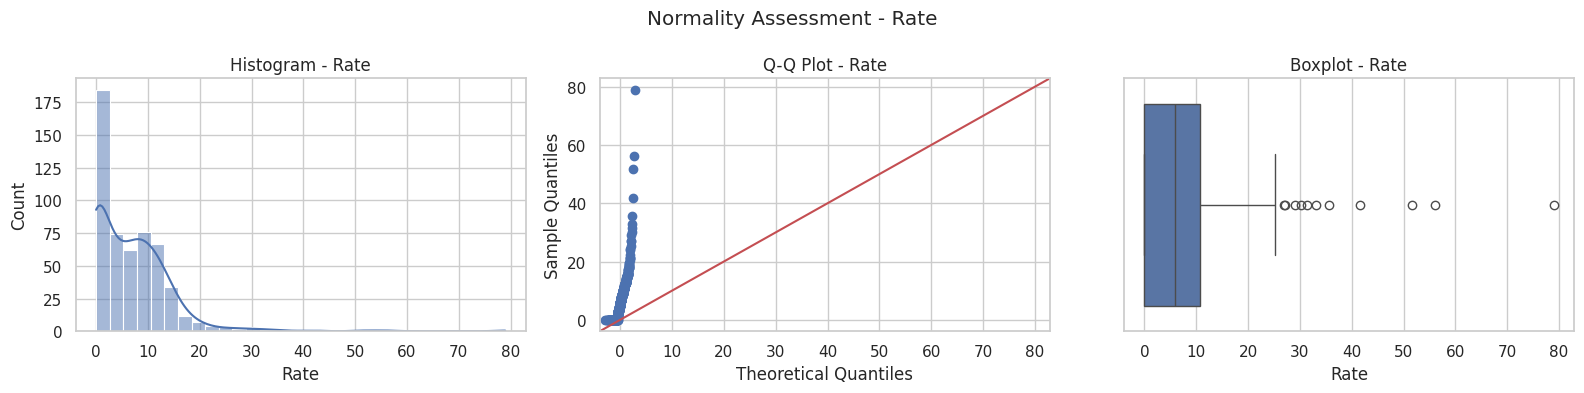

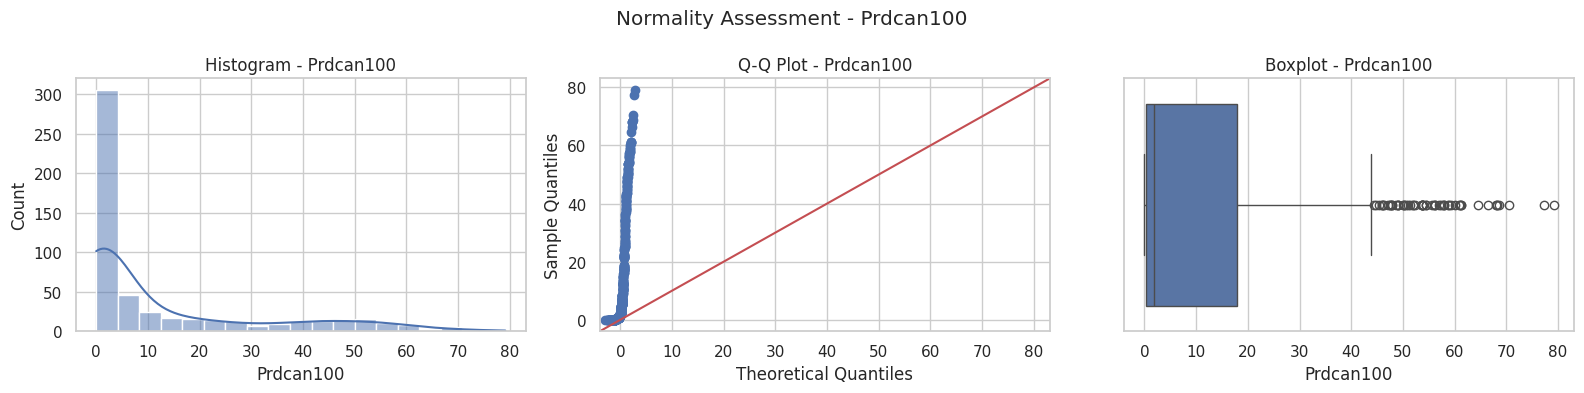

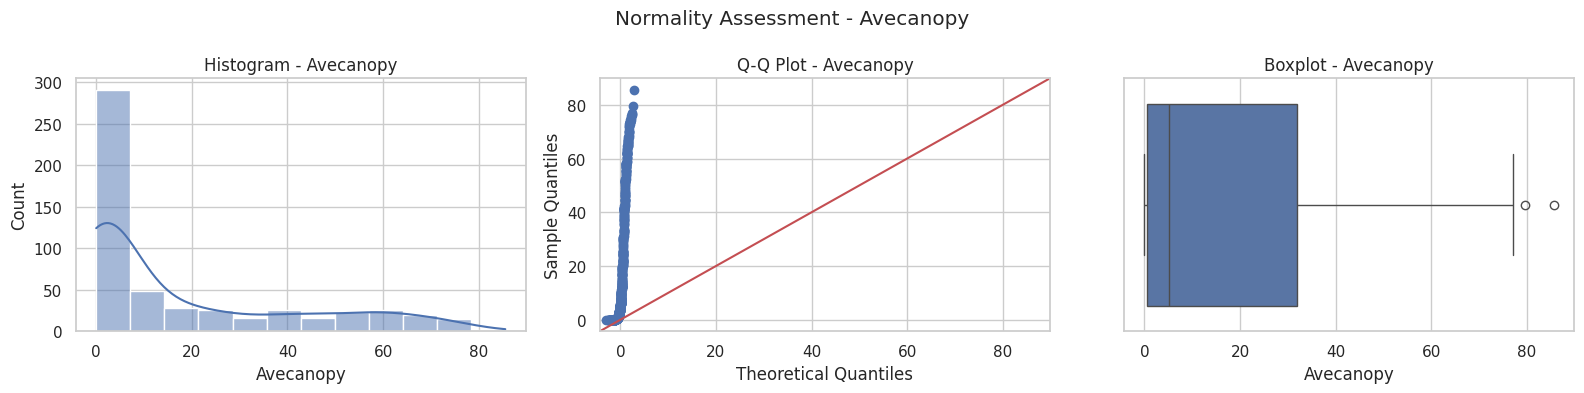

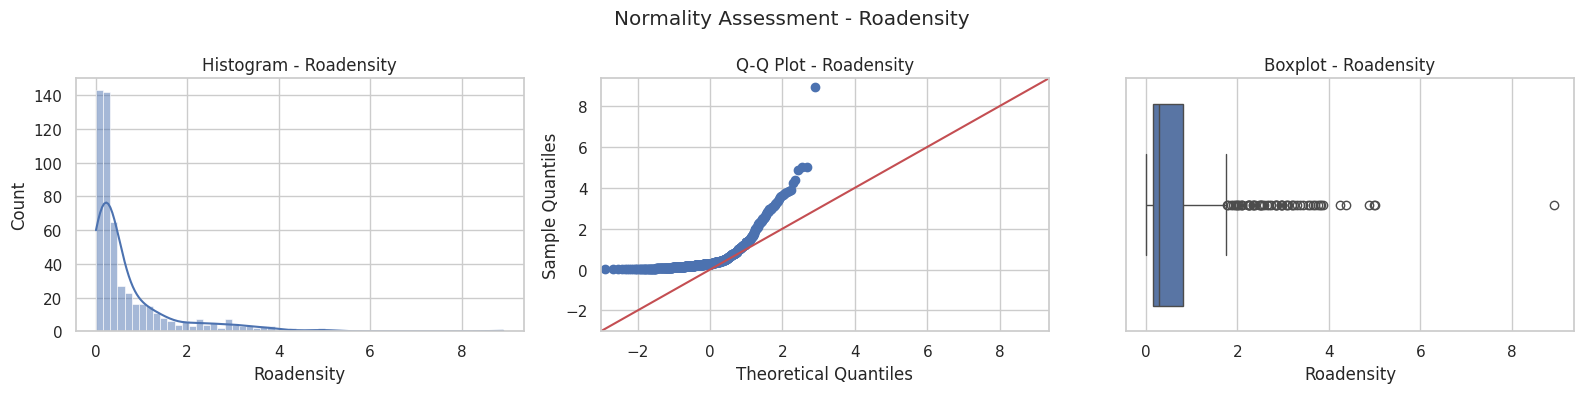

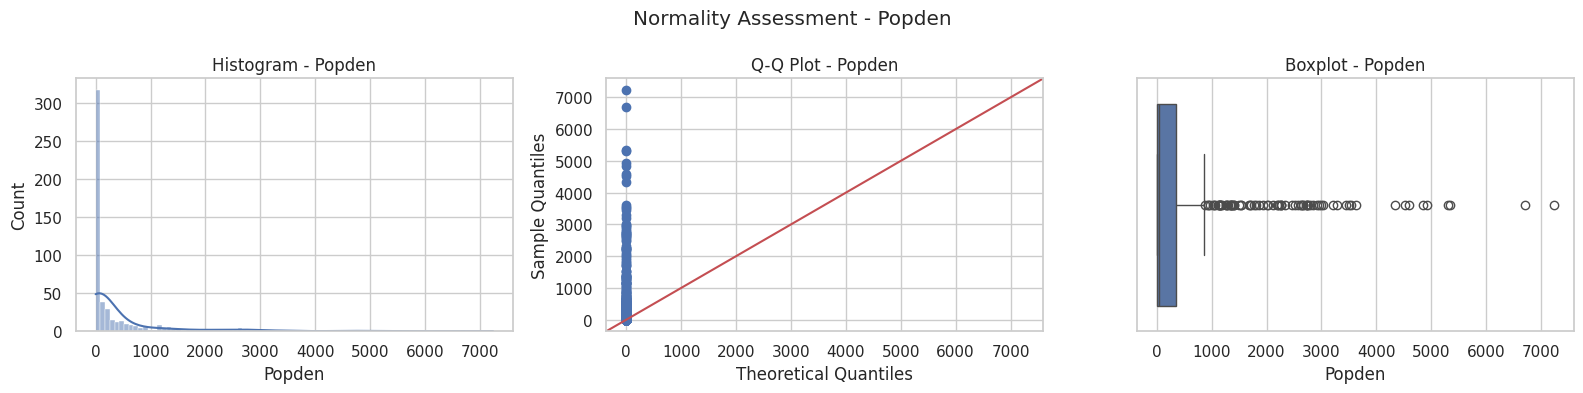

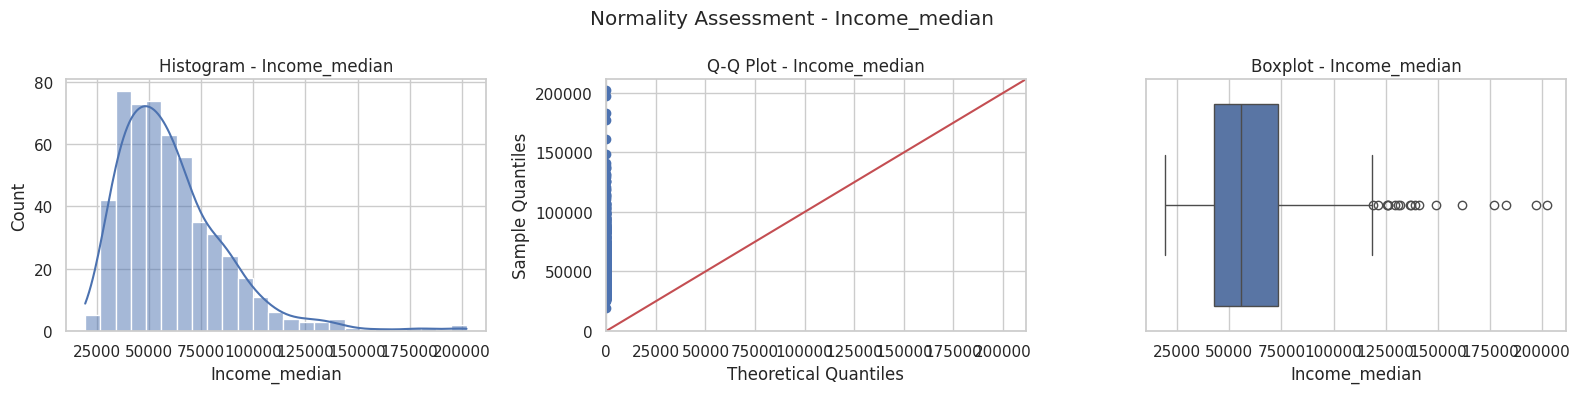

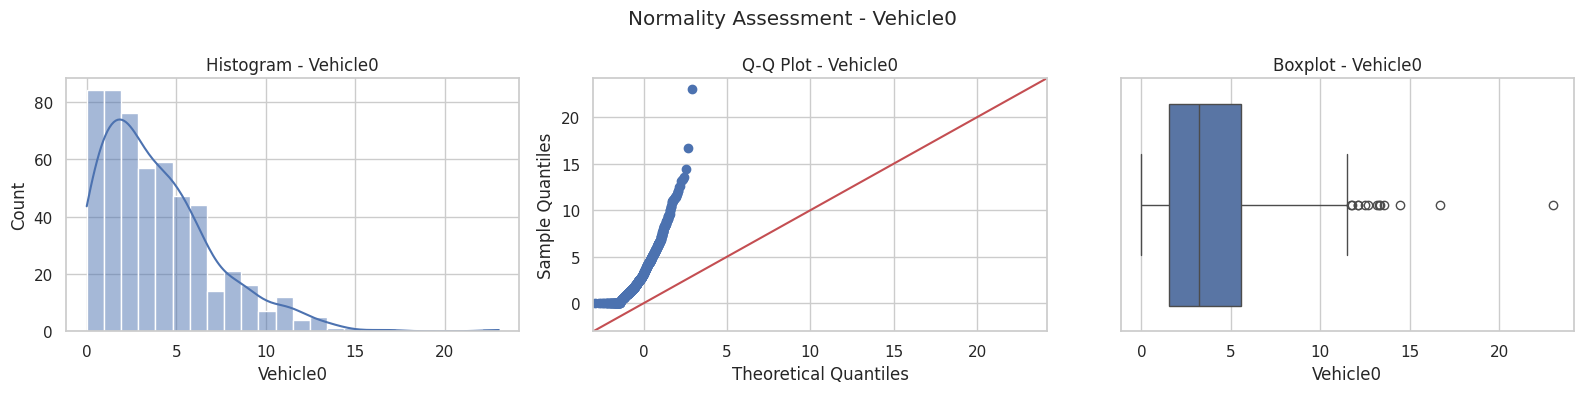

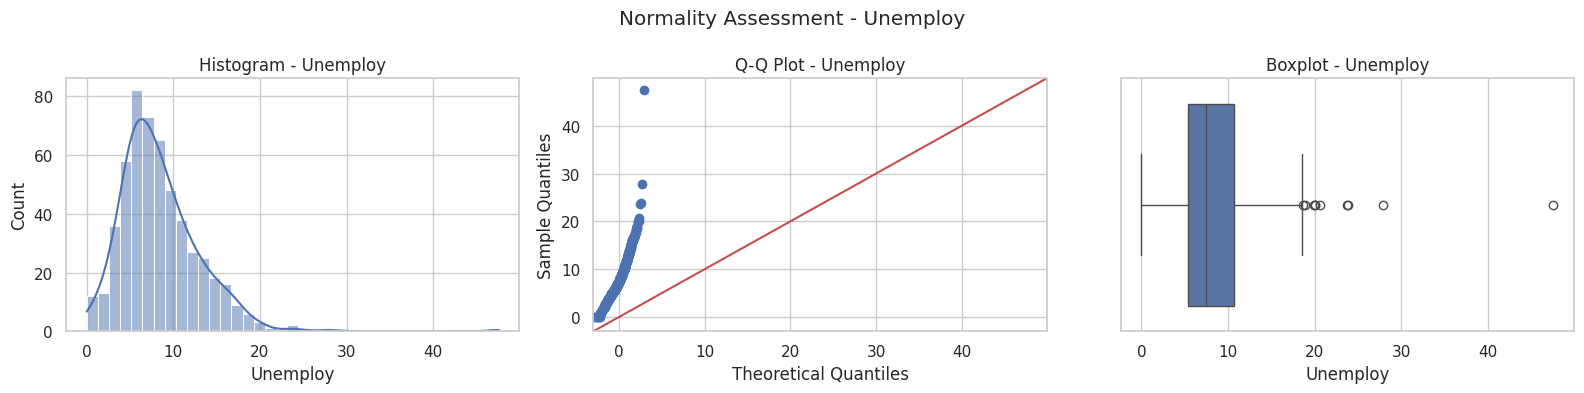

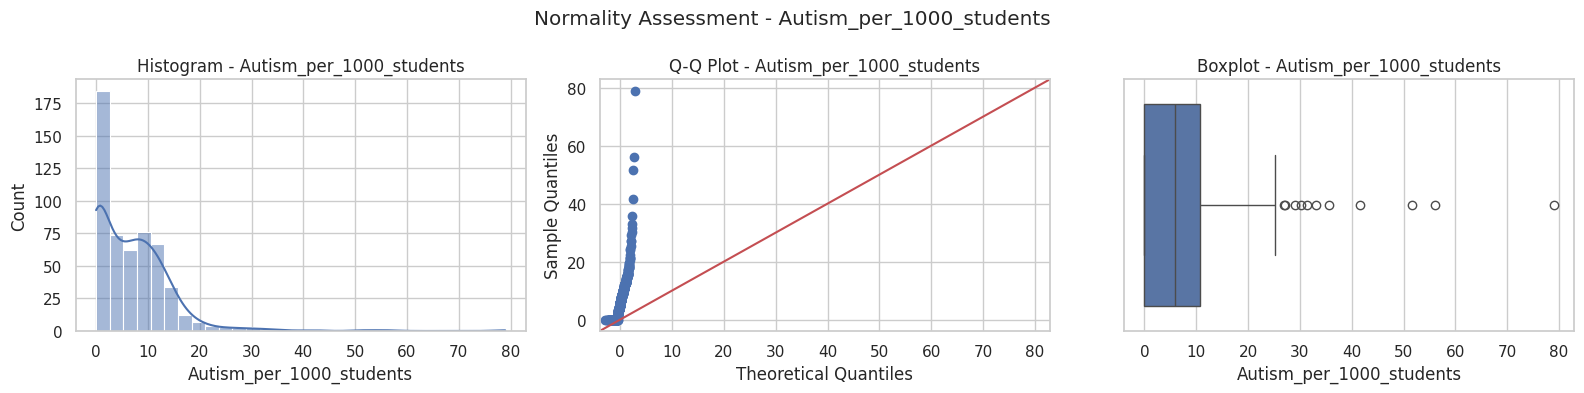

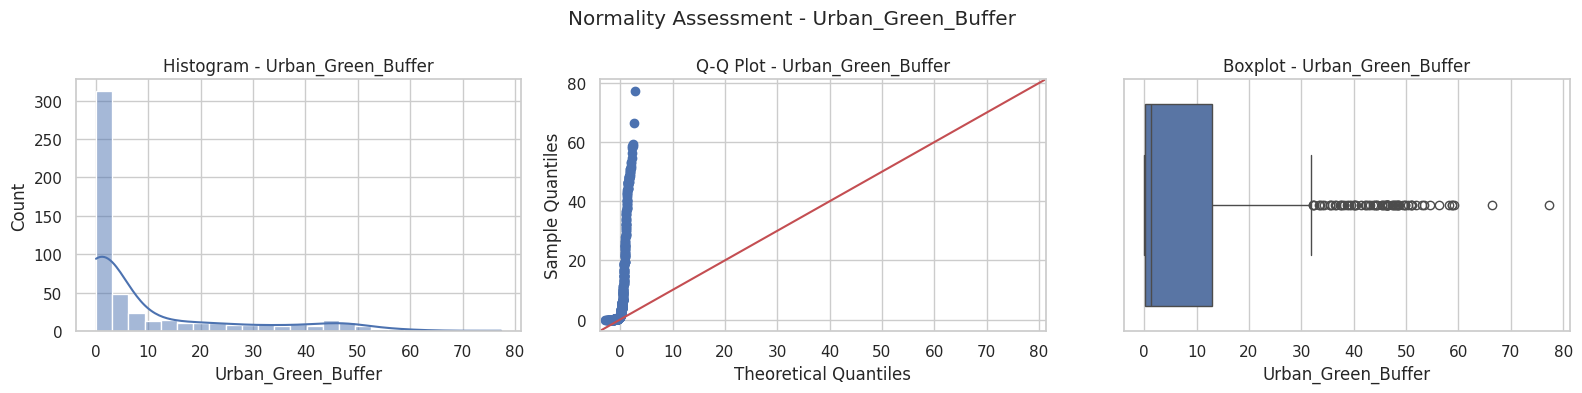

In [70]:
# Visual normality assessment for analysis variables

for col in analysis_vars:

    fig, axes = plt.subplots(1, 3, figsize=(16,4))

    # Histogram
    sns.histplot(
        df_clean[col],
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"Histogram - {col}")

    # Q-Q Plot
    sm.qqplot(
        df_clean[col],
        line='45',
        ax=axes[1]
    )
    axes[1].set_title(f"Q-Q Plot - {col}")

    # Boxplot
    sns.boxplot(
        x=df_clean[col],
        ax=axes[2]
    )
    axes[2].set_title(f"Boxplot - {col}")

    plt.suptitle(f"Normality Assessment - {col}")
    plt.tight_layout()
    plt.show()

The <font face='Arial' color='#48D1CC'>**Shapiro–Wilk test** </font>was conducted to determine whether each variable followed a normal distribution.

The hypotheses tested were:

<font face='Arial' color='#48D1CC'>H₀: The variable is normally distributed.</font>

<font face='Arial' color='#48D1CC'>H₁: The variable is not normally distributed.</font>

Decision rule:

<font face='Arial' color='#48D1CC'>p-value > 0.05: Fail to reject H₀ (approximately normal).</font>
<font face='Arial' color='#48D1CC'>p-value < 0.05: Reject H₀ (not normally distributed).</font>

The Shapiro–Wilk test was selected because it is widely regarded as one of the most powerful tests for assessing normality in continuous variables.

The results revealed that several variables were not normally distributed, indicating that non-parametric analytical techniques would be more appropriate for subsequent correlation analysis.

## **CORRELATION ANALYSIS**

In [71]:
# Examine relationships between autism prevalence and environmental variables
# using Spearman and Kendall rank-based correlation analysis

corr_vars = [
    "Rate", "Prdcan100", "Avecanopy", "Roadensity", "Popden",
    "Income_median", "Vehicle0", "Unemploy", "Urban_Green_Buffer"
]

spearman_corr = df_clean[corr_vars].corr(method="spearman")
kendall_corr = df_clean[corr_vars].corr(method="kendall")

print("Spearman Correlation Matrix:")
display(spearman_corr)

print("Kendall Correlation Matrix:")
display(kendall_corr)

rate_corr_results = []

for col in corr_vars:
    if col != "Rate":
        spearman_r, spearman_p = spearmanr(df_clean["Rate"], df_clean[col])
        kendall_r, kendall_p = kendalltau(df_clean["Rate"], df_clean[col])

        rate_corr_results.append({
            "Variable": col,
            "Spearman_r": spearman_r,
            "Spearman_p": spearman_p,
            "Kendall_tau": kendall_r,
            "Kendall_p": kendall_p
        })

rate_corr_table = pd.DataFrame(rate_corr_results)
display(rate_corr_table)

print("""
Interpretation:
Spearman and Kendall are prioritized because many variables are non-normal.
""")

Spearman Correlation Matrix:


,Rate,Prdcan100,Avecanopy,Roadensity,Popden,Income_median,Vehicle0,Unemploy,Urban_Green_Buffer
Rate,1.000000,0.034729,-0.021505,0.373820,0.498782,0.186035,0.218039,-0.036812,-0.014714
Prdcan100,0.034729,1.000000,0.942072,-0.229442,-0.172920,0.189209,-0.259141,-0.208104,0.988834
Avecanopy,-0.021505,0.942072,1.000000,-0.291785,-0.224333,0.152763,-0.268388,-0.184921,0.943573
Roadensity,0.373820,-0.229442,-0.291785,1.000000,0.864091,0.325981,0.308434,-0.120575,-0.345709
Popden,0.498782,-0.172920,-0.224333,0.864091,1.000000,0.333764,0.377770,-0.110061,-0.278043
Income_median,0.186035,0.189209,0.152763,0.325981,0.333764,1.000000,-0.371219,-0.566839,0.146645
Vehicle0,0.218039,-0.259141,-0.268388,0.308434,0.377770,-0.371219,1.000000,0.324158,-0.285287
Unemploy,-0.036812,-0.208104,-0.184921,-0.120575,-0.110061,-0.566839,0.324158,1.000000,-0.184881
Urban_Green_Buffer,-0.014714,0.988834,0.943573,-0.345709,-0.278043,0.146645,-0.285287,-0.184881,1.000000


Kendall Correlation Matrix:


,Rate,Prdcan100,Avecanopy,Roadensity,Popden,Income_median,Vehicle0,Unemploy,Urban_Green_Buffer
Rate,1.000000,0.029207,-0.008991,0.277421,0.369159,0.129390,0.146199,-0.024979,-0.005879
Prdcan100,0.029207,1.000000,0.804611,-0.150502,-0.116588,0.131403,-0.179712,-0.143772,0.917704
Avecanopy,-0.008991,0.804611,1.000000,-0.191599,-0.150856,0.106461,-0.184881,-0.128723,0.799659
Roadensity,0.277421,-0.150502,-0.191599,1.000000,0.685222,0.216679,0.205976,-0.080060,-0.233607
Popden,0.369159,-0.116588,-0.150856,0.685222,1.000000,0.220881,0.260605,-0.071006,-0.190691
Income_median,0.129390,0.131403,0.106461,0.216679,0.220881,1.000000,-0.256172,-0.405474,0.103434
Vehicle0,0.146199,-0.179712,-0.184881,0.205976,0.260605,-0.256172,1.000000,0.229316,-0.196362
Unemploy,-0.024979,-0.143772,-0.128723,-0.080060,-0.071006,-0.405474,0.229316,1.000000,-0.128621
Urban_Green_Buffer,-0.005879,0.917704,0.799659,-0.233607,-0.190691,0.103434,-0.196362,-0.128621,1.000000


,Variable,Spearman_r,Spearman_p,Kendall_tau,Kendall_p
0,Prdcan100,0.034729,4.231889e-01,0.029207,3.307371e-01
1,Avecanopy,-0.021505,6.200034e-01,-0.008991,7.642689e-01
2,Roadensity,0.373820,3.737026e-19,0.277421,2.000019e-20
3,Popden,0.498782,6.192913e-35,0.369159,6.123014e-35
4,Income_median,0.186035,1.513302e-05,0.129390,1.544998e-05
5,Vehicle0,0.218039,3.617229e-07,0.146199,1.126019e-06
6,Unemploy,-0.036812,3.959071e-01,-0.024979,4.042210e-01
7,Urban_Green_Buffer,-0.014714,7.344357e-01,-0.005879,8.446114e-01



Interpretation:
Spearman and Kendall are prioritized because many variables are non-normal.



Both methods were calculated for all analytical variables.

Spearman correlation measures the strength and direction of monotonic relationships between variables using ranked values rather than raw observations.

Kendall Tau evaluates the degree of agreement between ranked observations and provides a more conservative estimate of association.

<font face='Arial' color='#48D1CC'>**Spearman Rank Correlation**</font> was selected because several variables were found to be non-normally distributed based on the Shapiro–Wilk test. As a non-parametric method, Spearman correlation is more appropriate for assessing associations among variables that violate normality assumptions.

In [52]:
# Evaluate monotonic relationships between autism prevalence and
# environmental variables using Spearman Rank Correlation

corr_vars = [
    "Rate", "Prdcan100", "Avecanopy", "Roadensity", "Popden",
    "Income_median", "Vehicle0", "Unemploy", "Urban_Green_Buffer"
]

# Generate Spearman correlation matrix
spearman_corr = df_clean[corr_vars].corr(method="spearman")

print("Spearman Correlation Matrix:")
display(spearman_corr)

# Compute Spearman correlation coefficients and p-values
# between autism prevalence and each explanatory variable

rate_corr_results = []

for col in corr_vars:
    if col != "Rate":

        spearman_r, spearman_p = spearmanr(
            df_clean["Rate"],
            df_clean[col]
        )

        rate_corr_results.append({
            "Variable": col,
            "Spearman_r": spearman_r,
            "P_Value": spearman_p,
            "Decision": "Significant" if spearman_p < 0.05 else "Not Significant"
        })

rate_corr_table = pd.DataFrame(rate_corr_results)

print("Spearman Correlation Results with Autism Prevalence:")
display(rate_corr_table)

print("""
Interpretation:
- Spearman correlation measures the strength and direction of monotonic relationships.
- Positive coefficients indicate variables that increase together.
- Negative coefficients indicate inverse relationships.
- p-value < 0.05 indicates a statistically significant association.
- Spearman correlation was selected because several variables were found to be non-normally distributed based on the Shapiro-Wilk test.
""")

Spearman Correlation Matrix:


,Rate,Prdcan100,Avecanopy,Roadensity,Popden,Income_median,Vehicle0,Unemploy,Urban_Green_Buffer
Rate,1.000000,0.034729,-0.021505,0.373820,0.498782,0.186035,0.218039,-0.036812,-0.014714
Prdcan100,0.034729,1.000000,0.942072,-0.229442,-0.172920,0.189209,-0.259141,-0.208104,0.988834
Avecanopy,-0.021505,0.942072,1.000000,-0.291785,-0.224333,0.152763,-0.268388,-0.184921,0.943573
Roadensity,0.373820,-0.229442,-0.291785,1.000000,0.864091,0.325981,0.308434,-0.120575,-0.345709
Popden,0.498782,-0.172920,-0.224333,0.864091,1.000000,0.333764,0.377770,-0.110061,-0.278043
Income_median,0.186035,0.189209,0.152763,0.325981,0.333764,1.000000,-0.371219,-0.566839,0.146645
Vehicle0,0.218039,-0.259141,-0.268388,0.308434,0.377770,-0.371219,1.000000,0.324158,-0.285287
Unemploy,-0.036812,-0.208104,-0.184921,-0.120575,-0.110061,-0.566839,0.324158,1.000000,-0.184881
Urban_Green_Buffer,-0.014714,0.988834,0.943573,-0.345709,-0.278043,0.146645,-0.285287,-0.184881,1.000000


Spearman Correlation Results with Autism Prevalence:


,Variable,Spearman_r,P_Value,Decision
0,Prdcan100,0.034729,4.231889e-01,Not Significant
1,Avecanopy,-0.021505,6.200034e-01,Not Significant
2,Roadensity,0.373820,3.737026e-19,Significant
3,Popden,0.498782,6.192913e-35,Significant
4,Income_median,0.186035,1.513302e-05,Significant
5,Vehicle0,0.218039,3.617229e-07,Significant
6,Unemploy,-0.036812,3.959071e-01,Not Significant
7,Urban_Green_Buffer,-0.014714,7.344357e-01,Not Significant



Interpretation:
- Spearman correlation measures the strength and direction of monotonic relationships.
- Positive coefficients indicate variables that increase together.
- Negative coefficients indicate inverse relationships.
- p-value < 0.05 indicates a statistically significant association.
- Spearman correlation was selected because several variables were found to be non-normally distributed based on the Shapiro-Wilk test.



## **MULTICOLLINEARITY SCREENING USING CORRELATION MATRIX**

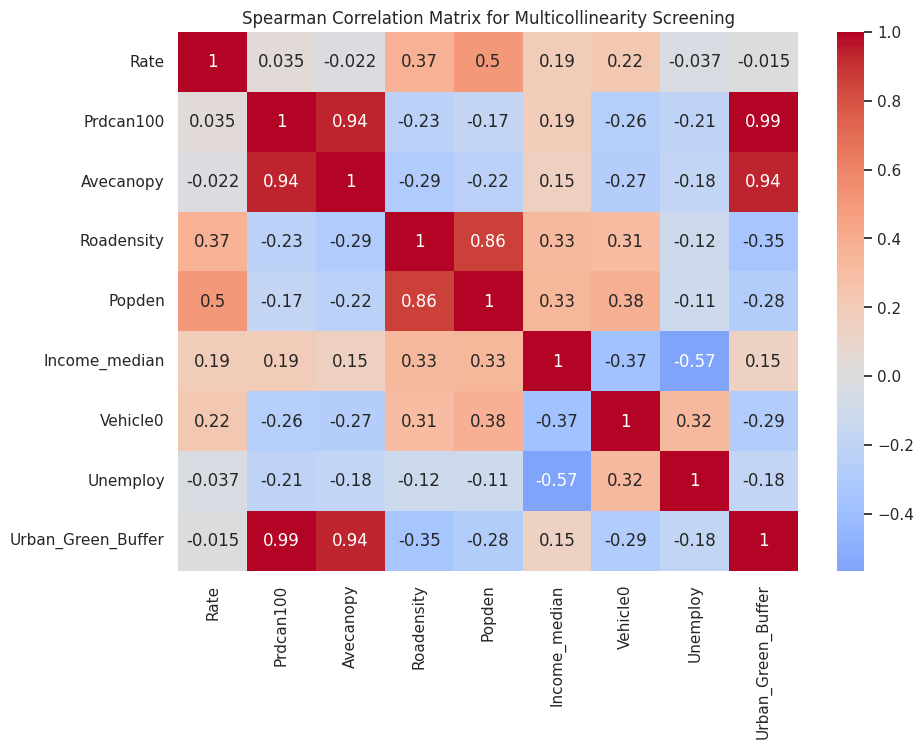

In [72]:
# Generate a Spearman correlation heatmap for multicollinearity screening

plt.figure(figsize=(10, 7))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Matrix for Multicollinearity Screening")
plt.show()

## **DATASET EDA VISUALIZATIONS**

In [73]:
# Explore relationships between autism prevalence and key environmental factors
# through interactive scatter plots and group-based distribution analysis

fig = px.scatter(
    df_clean,
    x="Prdcan100",
    y="Rate",
    size="Roadensity",
    color="Road_Group",
    hover_data=["DistrictID", "Autism", "Kstudent"],
    title="Near-Road Tree Canopy vs Autism Prevalence Rate"
)
fig.show()

fig = px.scatter(
    df_clean,
    x="Roadensity",
    y="Rate",
    color="Prdcan100",
    hover_data=["DistrictID"],
    title="Road Density vs Autism Prevalence Rate Colored by Near-Road Tree Canopy"
)
fig.show()

fig = px.violin(
    df_clean,
    x="Road_Group",
    y="Rate",
    box=True,
    points="all",
    title="Autism Prevalence Rate by Road Density Group"
)
fig.show()

## **ONE-HOT ENCODING FOR CATEGORICAL VARIABLES**

In [74]:
# Convert categorical road-density variables into numerical indicator variables
# to prepare the dataset for statistical modeling and dashboard analysis

df_encoded = pd.get_dummies(
    df_clean,
    columns=["Rd4", "Road_Group"],
    drop_first=False,
    dtype=int
)

print("One-hot encoded dashboard-ready structure:")
display(df_encoded.head())

print("Columns after encoding:")
print(df_encoded.columns.tolist())

One-hot encoded dashboard-ready structure:


,DistrictID,Autism,Kstudent,Rate,Prdcan100,Avecanopy,Roadensity,Popden,Income_median,Vehicle0,Unemploy,Autism_per_1000_students,Urban_Green_Buffer,Rd4_1,Rd4_2,Rd4_3,Rd4_4,Road_Group_High Road Density,Road_Group_Low Road Density,Road_Group_Moderate Road Density,Road_Group_Very Low Road Density
0,1,1,338,2.96,26.52,46.74,1.449,252.39,65139,2.46,3.58,2.958580,10.828910,0,0,0,1,1,0,0,0
1,2,54,5516,9.79,0.00,0.02,0.176,54.77,50395,5.76,16.71,9.789703,0.000000,0,1,0,0,0,1,0,0
2,3,0,111,0.00,10.14,32.25,0.090,7.34,75903,2.59,6.30,0.000000,9.302752,1,0,0,0,0,0,0,1
3,4,16,6837,2.34,0.06,13.93,0.298,325.11,48597,7.68,13.83,2.340208,0.046225,0,0,1,0,0,0,1,0
4,5,0,53,0.00,0.00,0.00,0.174,4.01,19375,16.67,47.56,0.000000,0.000000,0,1,0,0,0,1,0,0


Columns after encoding:
['DistrictID', 'Autism', 'Kstudent', 'Rate', 'Prdcan100', 'Avecanopy', 'Roadensity', 'Popden', 'Income_median', 'Vehicle0', 'Unemploy', 'Autism_per_1000_students', 'Urban_Green_Buffer', 'Rd4_1', 'Rd4_2', 'Rd4_3', 'Rd4_4', 'Road_Group_High Road Density', 'Road_Group_Low Road Density', 'Road_Group_Moderate Road Density', 'Road_Group_Very Low Road Density']


## **DATA STANDARDIZATION USING Z-SCORE TRANSFORMATION**

In [75]:
# Standardize environmental, urban, and socioeconomic variables using
# Z-score transformation while preserving the original values

dashboard_df = df_encoded.copy()

scale_cols = [
    "Rate", "Prdcan100", "Avecanopy", "Roadensity", "Popden",
    "Income_median", "Vehicle0", "Unemploy",
    "Autism_per_1000_students", "Urban_Green_Buffer"
]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(dashboard_df[scale_cols])

for i, col in enumerate(scale_cols):
    dashboard_df[col + "_scaled"] = scaled_values[:, i]

print("Original and standardized values preserved:")
display(dashboard_df.head())

Original and standardized values preserved:


,DistrictID,Autism,Kstudent,Rate,Prdcan100,Avecanopy,Roadensity,Popden,Income_median,Vehicle0,Unemploy,Autism_per_1000_students,Urban_Green_Buffer,Rd4_1,Rd4_2,Rd4_3,Rd4_4,Road_Group_High Road Density,Road_Group_Low Road Density,Road_Group_Moderate Road Density,Road_Group_Very Low Road Density,Rate_scaled,Prdcan100_scaled,Avecanopy_scaled,Roadensity_scaled,Popden_scaled,Income_median_scaled,Vehicle0_scaled,Unemploy_scaled,Autism_per_1000_students_scaled,Urban_Green_Buffer_scaled
0,1,1,338,2.96,26.52,46.74,1.449,252.39,65139,2.46,3.58,2.958580,10.828910,0,0,0,1,1,0,0,0,-0.504773,0.740247,1.235984,0.775071,-0.205989,0.161946,-0.460596,-1.054036,-0.504935,0.057298
1,2,54,5516,9.79,0.00,0.02,0.176,54.77,50395,5.76,16.71,9.789703,0.000000,0,1,0,0,0,1,0,0,0.378506,-0.673244,-0.779489,-0.535656,-0.411792,-0.407067,0.574490,1.826933,0.378487,-0.629348
2,3,0,111,0.00,10.14,32.25,0.090,7.34,75903,2.59,6.30,0.000000,9.302752,1,0,0,0,0,0,0,1,-0.887571,-0.132792,0.610894,-0.624205,-0.461185,0.577359,-0.419820,-0.457217,-0.887548,-0.039473
3,4,16,6837,2.34,0.06,13.93,0.298,325.11,48597,7.68,13.83,2.340208,0.046225,0,0,1,0,0,0,1,0,-0.584954,-0.670046,-0.179420,-0.410040,-0.130258,-0.476457,1.176722,1.195007,-0.584905,-0.626417
4,5,0,53,0.00,0.00,0.00,0.174,4.01,19375,16.67,47.56,0.000000,0.000000,0,1,0,0,0,1,0,0,-0.887571,-0.673244,-0.780352,-0.537715,-0.464653,-1.604216,3.996548,8.596003,-0.887548,-0.629348


To ensure comparability among predictors measured on different scales, standardization was performed using the z-score transformation:

**Z = (X − Mean) ÷ Standard Deviation**

After transformation, all standardized variables had a mean of zero and a standard deviation of one.

Standardization prevents variables with large numerical ranges from dominating regression estimates and allows direct comparison of coefficient magnitudes.

In [76]:
# Inspect prior dashboard dataset

display(dashboard_df.head())
print("Dashboard dataset shape:", dashboard_df.shape)

,DistrictID,Autism,Kstudent,Rate,Prdcan100,Avecanopy,Roadensity,Popden,Income_median,Vehicle0,Unemploy,Autism_per_1000_students,Urban_Green_Buffer,Rd4_1,Rd4_2,Rd4_3,Rd4_4,Road_Group_High Road Density,Road_Group_Low Road Density,Road_Group_Moderate Road Density,Road_Group_Very Low Road Density,Rate_scaled,Prdcan100_scaled,Avecanopy_scaled,Roadensity_scaled,Popden_scaled,Income_median_scaled,Vehicle0_scaled,Unemploy_scaled,Autism_per_1000_students_scaled,Urban_Green_Buffer_scaled
0,1,1,338,2.96,26.52,46.74,1.449,252.39,65139,2.46,3.58,2.958580,10.828910,0,0,0,1,1,0,0,0,-0.504773,0.740247,1.235984,0.775071,-0.205989,0.161946,-0.460596,-1.054036,-0.504935,0.057298
1,2,54,5516,9.79,0.00,0.02,0.176,54.77,50395,5.76,16.71,9.789703,0.000000,0,1,0,0,0,1,0,0,0.378506,-0.673244,-0.779489,-0.535656,-0.411792,-0.407067,0.574490,1.826933,0.378487,-0.629348
2,3,0,111,0.00,10.14,32.25,0.090,7.34,75903,2.59,6.30,0.000000,9.302752,1,0,0,0,0,0,0,1,-0.887571,-0.132792,0.610894,-0.624205,-0.461185,0.577359,-0.419820,-0.457217,-0.887548,-0.039473
3,4,16,6837,2.34,0.06,13.93,0.298,325.11,48597,7.68,13.83,2.340208,0.046225,0,0,1,0,0,0,1,0,-0.584954,-0.670046,-0.179420,-0.410040,-0.130258,-0.476457,1.176722,1.195007,-0.584905,-0.626417
4,5,0,53,0.00,0.00,0.00,0.174,4.01,19375,16.67,47.56,0.000000,0.000000,0,1,0,0,0,1,0,0,-0.887571,-0.673244,-0.780352,-0.537715,-0.464653,-1.604216,3.996548,8.596003,-0.887548,-0.629348


Dashboard dataset shape: (534, 31)


In [77]:
# To saved prior dashboard dataset

dashboard_output_name = "autism_green_space.csv"

dashboard_df.to_csv(dashboard_output_name, index=False)

files.download(dashboard_output_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **High-Road-Density Modeling**

In [78]:
# Create a high-road-density subset for focused environmental exposure analysis

model_df = dashboard_df[dashboard_df['Roadensity'] >= dashboard_df['Roadensity'].median()].copy()

print(model_df.shape)

(267, 31)


### **High-Road-Density Subgroup Analysis**

The original study reported stronger green-space associations in districts characterized by higher roadway exposure.

To replicate this analytical focus, a subset of districts with road density values greater than or equal to the median road density was created.

This high-road-density subset served as the primary dataset for regression modeling.

The purpose of this approach was to evaluate environmental buffering effects under conditions of elevated transportation exposure.

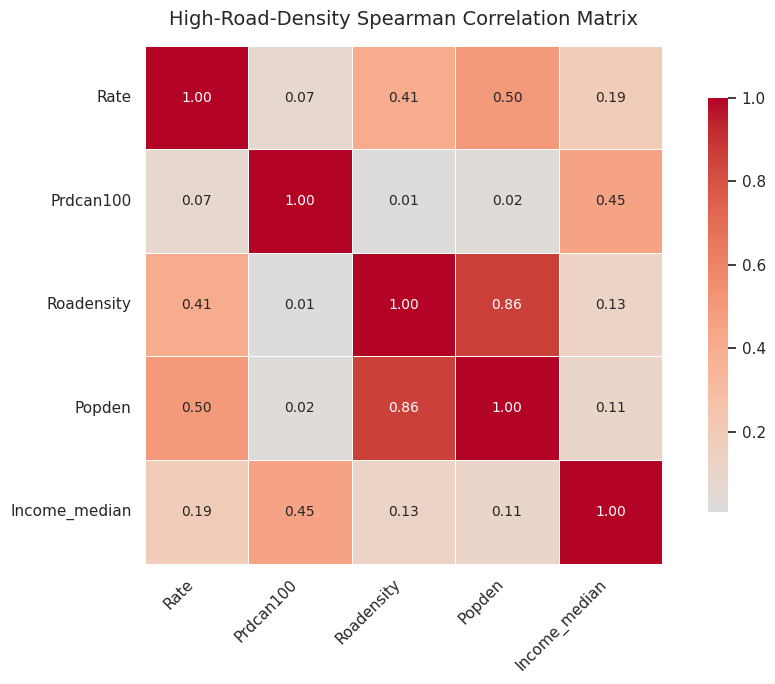

In [109]:
# Examine associations among selected variables within high-road-density districts
# using Spearman correlation to identify environmental relationship patterns

corr_vars = [
    'Rate',
    'Prdcan100',
    'Roadensity',
    'Popden',
    'Income_median',
    'Green_Buffer_Score'
]

# Keep only columns that exist in model_df
corr_vars = [col for col in corr_vars if col in model_df.columns]

model_corr = model_df[corr_vars].corr(method='spearman')

plt.figure(figsize=(10, 7))

sns.heatmap(
    model_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.8}
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("High-Road-Density Spearman Correlation Matrix", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [81]:
# Define the predictor variables and response variable
# for regression modeling within the high-road-density subset

predictors = [
    'Prdcan100_scaled',
    'Roadensity_scaled',
    'Popden_scaled',
    'Income_median_scaled',
    'Vehicle0_scaled',
    'Unemploy_scaled'
]

X = model_df[predictors]

y = model_df['Rate']

In [82]:
# Add an intercept (constant term) to the regression model

X = sm.add_constant(X)

In [83]:
# Variance Inflation Factor

vif_data = pd.DataFrame()

vif_data["Variable"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

display(vif_data)

,Variable,VIF
0,const,1.549146
1,Prdcan100_scaled,1.304726
2,Roadensity_scaled,2.764451
3,Popden_scaled,2.894305
4,Income_median_scaled,1.850680
5,Vehicle0_scaled,1.531227
6,Unemploy_scaled,1.581710


## **Multicollinearity Assessment**

Before regression modeling, multicollinearity among predictors was evaluated.

Initially, a Spearman correlation heatmap was examined to identify highly correlated variables.

Variance Inflation Factors (VIF) were then computed for each predictor using:

**VIF = 1 / (1 − R²)**

High VIF values indicate that a variable shares substantial information with other predictors and may destabilize regression estimates.

This step ensured that the explanatory variables contributed unique information to the model.

In [84]:
# OLS baseline model

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.166
Method:                 Least Squares   F-statistic:                     9.803
Date:                Sun, 31 May 2026   Prob (F-statistic):           9.63e-10
Time:                        06:05:02   Log-Likelihood:                -823.62
No. Observations:                 267   AIC:                             1661.
Df Residuals:                     260   BIC:                             1686.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    7.0213 

### **Ordinary Least Squares (OLS) Regression**

A multiple linear regression model was first estimated using <font face='Arial' color='#48D1CC'>**Ordinary Least Squares (OLS).**</font>


The dependent variable was autism prevalence rate.

The predictor variables included:



*   Near-road tree canopy
*   Road density
*   Population density
*   Median household income
*   Vehicle access indicator
*   Unemployment indicator

OLS regression estimates coefficients by minimizing the sum of squared residuals between observed and predicted values.

The model produced:

*   Regression coefficients
*   Standard errors
*   t-statistics
*   p-values
*   Goodness-of-fit measures

These outputs were used to determine which environmental and socioeconomic variables were statistically associated with autism prevalence.

In [85]:
# Residual normality testing

residuals = ols_model.resid

stat, p = shapiro(residuals)

print("Shapiro-Wilk P-Value:", p)

Shapiro-Wilk P-Value: 9.813429976903875e-08


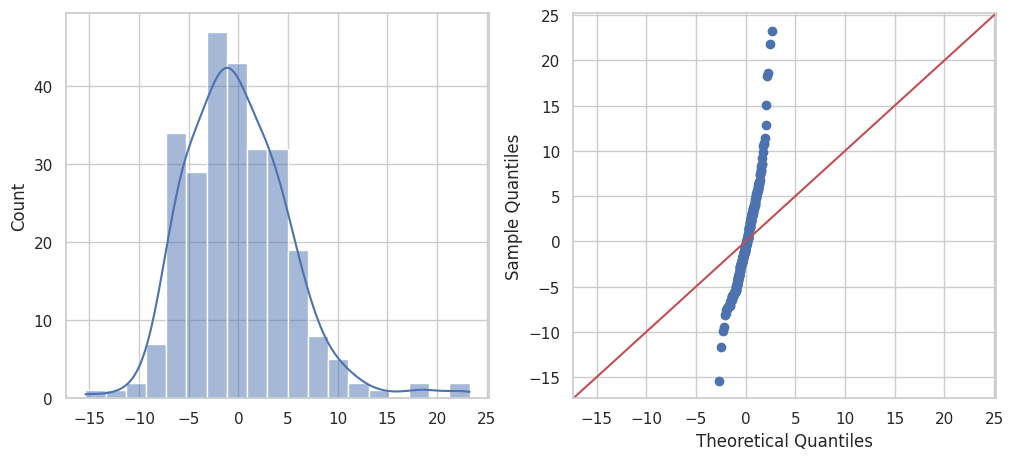

In [86]:
# Residual visualization


fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.histplot(residuals, kde=True, ax=ax[0])
F
sm.qqplot(residuals, line='45', ax=ax[1])

plt.show()

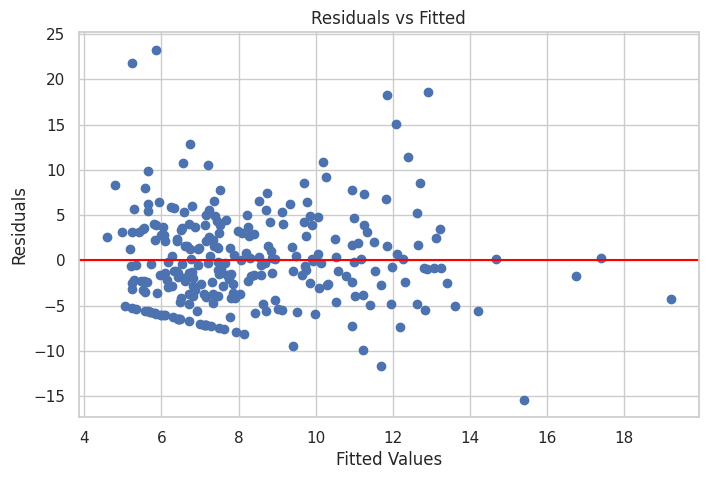

In [87]:
# Residuals vs fitted plot

plt.figure(figsize=(8,5))

plt.scatter(ols_model.fittedvalues, residuals)

plt.axhline(0, color='red')

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Fitted")

plt.show()

In [88]:
# Breusch-Pagan test

bp_test = het_breuschpagan(
    residuals,
    ols_model.model.exog
)

labels = [
    'LM Statistic',
    'LM-Test p-value',
    'F-Statistic',
    'F-Test p-value'
]

print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(23.143625903012126), 'LM-Test p-value': np.float64(0.0007497741797971131), 'F-Statistic': np.float64(4.1126276051259465), 'F-Test p-value': np.float64(0.0005796759728908606)}


### **Heteroscedasticity Testing**

The <font face='Arial' color='#48D1CC'>**Breusch–Pagan test**</font> was conducted to evaluate heteroscedasticity.

The hypotheses tested were:

* H₀: Residual variance is constant.

* H₁: Residual variance is not constant.

Decision rule:

* p-value > 0.05: Homoscedasticity assumed.
* p-value < 0.05: Heteroscedasticity present.

This test was selected because unequal residual variance can produce unreliable standard errors and significance tests within OLS regression.

In [89]:
# Huber Robust Regression

huber_model = sm.RLM(
    y,
    X,
    M=sm.robust.norms.HuberT()
).fit()

print(huber_model.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:                   Rate   No. Observations:                  267
Model:                            RLM   Df Residuals:                      260
Method:                          IRLS   Df Model:                            6
Norm:                          HuberT                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 31 May 2026                                         
Time:                        06:05:15                                         
No. Iterations:                    16                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    6.3553 

In [90]:
# Tukey Robust Regression

tukey_model = sm.RLM(
    y,
    X,
    M=sm.robust.norms.TukeyBiweight()
).fit()

print(tukey_model.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:                   Rate   No. Observations:                  267
Model:                            RLM   Df Residuals:                      260
Method:                          IRLS   Df Model:                            6
Norm:                   TukeyBiweight                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 31 May 2026                                         
Time:                        06:05:17                                         
No. Iterations:                    15                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    6.1424 

In [91]:
# Hampel Robust Regression

hampel_model = sm.RLM(
    y,
    X,
    M=sm.robust.norms.Hampel()
).fit()

print(hampel_model.summary())

                    Robust linear Model Regression Results                    
Dep. Variable:                   Rate   No. Observations:                  267
Model:                            RLM   Df Residuals:                      260
Method:                          IRLS   Df Model:                            6
Norm:                          Hampel                                         
Scale Est.:                       mad                                         
Cov Type:                          H1                                         
Date:                Sun, 31 May 2026                                         
Time:                        06:05:19                                         
No. Iterations:                    14                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    6.5598 

In [92]:
# Compare model coefficients

comparison = pd.DataFrame({
    "OLS": ols_model.params,
    "Huber": huber_model.params,
    "Tukey": tukey_model.params,
    "Hampel": hampel_model.params
})

display(comparison)


,OLS,Huber,Tukey,Hampel
const,7.021310,6.355332,6.142376,6.559772
Prdcan100_scaled,-0.578246,-1.168218,-1.455417,-1.129503
Roadensity_scaled,0.505005,0.615711,0.620557,0.551704
Popden_scaled,1.389267,1.184955,1.121703,1.260117
Income_median_scaled,1.180741,1.546967,1.649666,1.448030
Vehicle0_scaled,-0.205802,0.244682,0.396014,0.103035
Unemploy_scaled,0.248246,0.253882,0.229704,0.258140


### **Robust Regression Modeling**

Because the diagnostic procedures revealed skewness, outliers, and violations of OLS assumptions, robust regression techniques were evaluated.

Three robust models were estimated:

<font face='Arial' color='#48D1CC'>**Huber Regression**</font>

Reduces the influence of extreme residuals while maintaining efficiency for ordinary observations.

<font face='Arial' color='#48D1CC'>**Tukey Biweight Regression**</font>

Applies stronger down-weighting to extreme observations.

<font face='Arial' color='#48D1CC'>**Hampel Regression**</font>

Uses piecewise weighting to limit the influence of increasingly large residuals.

The coefficients from all three robust methods were compared against OLS estimates.

<font face='Arial' color='#48D1CC'>**Huber Robust Regression**</font> was selected as the final model because:

- Residual normality assumptions were violated
- The dataset contains skewness and potential outliers
- It is less sensitive to extreme observations than OLS
- Residual diagnostics suggested violations of classical OLS assumptions.
- Huber regression balances robustness and stability

In [93]:
# Create a copy of the cleaned dataset
final_dashboard_df = df.copy()

In [95]:
# Compute the Green Buffer Score to represent environmental protection
# relative to roadway exposure conditions

final_dashboard_df['Green_Buffer_Score'] = (
    final_dashboard_df['Prdcan100']
    /
    (final_dashboard_df['Roadensity'] + 1)
)


In [96]:
# Classify districts into high and low roadway exposure groups
# based on the median road density threshold

final_dashboard_df['Road_Density_Group'] = np.where(
    final_dashboard_df['Roadensity']
    >=
    final_dashboard_df['Roadensity'].median(),

    'High Road Density',
    'Low Road Density'
)

In [98]:
# Define final columns to be used for dashboarding

final_columns = [

    'DistrictID',
    'Rate',
    'Prdcan100',
    'Roadensity',
    'Popden',
    'Income_median',
    'Green_Buffer_Score',
    'Road_Density_Group'
]

final_dashboard_df = final_dashboard_df[final_columns]


In [97]:
# Show first five row of the final dataset

display(final_dashboard_df.head())

,DistrictID,Autism,Kstudent,Rate,Prdcan100,Avecanopy,Roadensity,Popden,Income_median,Vehicle0,Unemploy,Rd4,Green_Buffer_Score,Road_Density_Group
0,1,1,338,2.96,26.52,46.74,1.449,252.39,65139,2.46,3.58,4,10.828910,High Road Density
1,2,54,5516,9.79,0.00,0.02,0.176,54.77,50395,5.76,16.71,2,0.000000,Low Road Density
2,3,0,111,0.00,10.14,32.25,0.090,7.34,75903,2.59,6.30,1,9.302752,Low Road Density
3,4,16,6837,2.34,0.06,13.93,0.298,325.11,48597,7.68,13.83,3,0.046225,High Road Density
4,5,0,53,0.00,0.00,0.00,0.174,4.01,19375,16.67,47.56,2,0.000000,Low Road Density


In [101]:
# Check the final number of rows and columns in the dashboard dataset

print(final_dashboard_df.shape)

(543, 9)


In [100]:
# Convert road density categories into binary indicator variables
# to prepare the final dataset for dashboard filtering and analysis

final_dashboard_df = pd.get_dummies(
    final_dashboard_df,
    columns=['Road_Density_Group'],
    drop_first=False
)

display(final_dashboard_df.head())

,DistrictID,Rate,Prdcan100,Roadensity,Popden,Income_median,Green_Buffer_Score,Road_Density_Group_High Road Density,Road_Density_Group_Low Road Density
0,1,2.96,26.52,1.449,252.39,65139,10.828910,True,False
1,2,9.79,0.00,0.176,54.77,50395,0.000000,False,True
2,3,0.00,10.14,0.090,7.34,75903,9.302752,False,True
3,4,2.34,0.06,0.298,325.11,48597,0.046225,True,False
4,5,0.00,0.00,0.174,4.01,19375,0.000000,False,True


In [102]:
# Standardize selected dashboard variables using Z-score transformation
# while preserving the original values for interpretation and visualization

scale_columns = [

    'Rate',
    'Prdcan100',
    'Roadensity',
    'Popden',
    'Income_median',
    'Green_Buffer_Score'
]

scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    final_dashboard_df[scale_columns]
)

scaled_df = pd.DataFrame(
    scaled_values,
    columns=[col + '_scaled' for col in scale_columns],
    index=final_dashboard_df.index
)

# Merge scaled columns
final_dashboard_df = pd.concat(
    [final_dashboard_df, scaled_df],
    axis=1
)

display(final_dashboard_df.head())

,DistrictID,Rate,Prdcan100,Roadensity,Popden,Income_median,Green_Buffer_Score,Road_Density_Group_High Road Density,Road_Density_Group_Low Road Density,Rate_scaled,Prdcan100_scaled,Roadensity_scaled,Popden_scaled,Income_median_scaled,Green_Buffer_Score_scaled
0,1,2.96,26.52,1.449,252.39,65139,10.828910,True,False,-0.500219,0.740853,0.788501,-0.201397,0.165417,0.057740
1,2,9.79,0.00,0.176,54.77,50395,0.000000,False,True,0.379353,-0.673959,-0.528084,-0.408561,-0.404459,-0.629520
2,3,0.00,10.14,0.090,7.34,75903,9.302752,False,True,-0.881410,-0.133001,-0.617029,-0.458281,0.581460,-0.039118
3,4,2.34,0.06,0.298,325.11,48597,0.046225,True,False,-0.580063,-0.670758,-0.401907,-0.125165,-0.473955,-0.626587
4,5,0.00,0.00,0.174,4.01,19375,0.000000,False,True,-0.881410,-0.673959,-0.530153,-0.461772,-1.603425,-0.629520


In [103]:
# Display the final number of observations and variables

print("FINAL DATASET SHAPE:")
print(final_dashboard_df.shape)

FINAL DATASET SHAPE:
(543, 15)


In [106]:
# Display the final list of variables included in the dashboard dataset

print("\nFINAL COLUMNS:")
print(final_dashboard_df.columns.tolist())


FINAL COLUMNS:
['DistrictID', 'Rate', 'Prdcan100', 'Roadensity', 'Popden', 'Income_median', 'Green_Buffer_Score', 'Road_Density_Group_High Road Density', 'Road_Density_Group_Low Road Density', 'Rate_scaled', 'Prdcan100_scaled', 'Roadensity_scaled', 'Popden_scaled', 'Income_median_scaled', 'Green_Buffer_Score_scaled']


In [105]:
# Check for remaining missing values in the final dashboard dataset

print("\nMISSING VALUES:")
print(final_dashboard_df.isnull().sum())


MISSING VALUES:
DistrictID                              0
Rate                                    0
Prdcan100                               8
Roadensity                              0
Popden                                  0
Income_median                           0
Green_Buffer_Score                      8
Road_Density_Group_High Road Density    0
Road_Density_Group_Low Road Density     0
Rate_scaled                             0
Prdcan100_scaled                        8
Roadensity_scaled                       0
Popden_scaled                           0
Income_median_scaled                    0
Green_Buffer_Score_scaled               8
dtype: int64


In [104]:
# Check for duplicated values in the final dashboard dataset

print("\nDUPLICATES:")
print(final_dashboard_df.duplicated().sum())


DUPLICATES:
0


In [107]:
# Save and download the final dashboard dataset

final_dashboard_df.to_csv(
    "AUTISM_GREENSPACE_DATASET.csv",
    index=False
)

print("""
FINAL DASHBOARD DATASET EXPORTED SUCCESSFULLY
""")

files.download(
    "AUTISM_GREENSPACE_DATASET.csv"
)


FINAL DASHBOARD DATASET EXPORTED SUCCESSFULLY



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Following statistical analysis, a streamlined dataset was prepared for dashboard deployment.

Only variables directly relevant to the research question and supported by literature were retained:

- District ID
- Autism prevalence rate
- Near-road tree canopy
- Road density
- Population density
- Median household income
- Green Buffer Score
- Road Density Group

Additional standardization and categorical encoding were performed to support dashboard filtering, visualization, and simulation features.

The final dataset was exported as a clean dashboard-ready file for interactive analysis and decision-support visualization.